In [51]:
import pandas as pd
from pathlib import Path
import numpy as np
import seaborn as sns
import random as rand
# from posydon.popsyn.binarypopulation import BinaryPopulation
# from posydon.binary_evol.binarystar import BinaryStar
# from posydon.binary_evol.singlestar import SingleStar
from posydon.popsyn.synthetic_population import Population
# from posydon.popsyn.synthetic_population import PopulationRunner
# import astropy.units as u
# 
# import os
# import shutil
# from posydon.config import PATH_TO_POSYDON

from POSYDONHRDiagramModule import HR_Diagram

import matplotlib.pyplot as plt
import matplotlib as mpl

import random as rand 

from collections import Counter

DataPath = Path().resolve().parent / 'Data'


In [52]:
cols = ['time', 'step_names', 'state', 'event', 'S1_state', 'S2_state', 'S1_mass', 'S2_mass', 'orbital_period']
finCols = [
    'orbital_period_f',
    'eccentricity_f',
    'state_f',

    'S1_state_f',
    'S2_state_f',
    
    'S2_mass_f',
    'S2_log_R_f',
    'S2_log_L_f',


    'S1_mass_f',
    'S1_log_R_f',
    'S1_log_L_f'

 ]

initCols = [
    'orbital_period_i',
    'eccentricity_i',
    'state_i',

    'S2_state_i',
    'S2_mass_i',
    'S2_log_R_i',

    'S1_state_i',
    'S1_mass_i',
    'S1_log_R_i'
 ]

In [53]:
mpl.rcParams.update({
    "pgf.texsystem": "pdflatex",  
    "font.family": "serif",       
    "text.usetex": True,          
    "pgf.rcfonts": False,         
})

In [54]:
def basicColHist(df, var: str, title: str | None = None, xLabel: str | None = None, saveFig: bool = False, savePath: Path = Path()) -> None:
    fig, ax = plt.subplots(figsize=(8,5))
    
    sns.histplot(df[var], bins=50, ax=ax)
    
    if title is None:
        title = f'{var} of BH-Sol systems at S1 SN'
    if xLabel is None:
        xLabel = var

    ax.set_title(title)
    ax.set_xlabel(xLabel)
    ax.set_ylabel('Count')

    if saveFig:
        clean_name = title.replace(' ', '_').replace('/', '-') + '.pgf'
        plt.savefig(savePath / clean_name, bbox_inches='tight')

    plt.show()

def genVarHist(var: list, title: str | None = None, xLabel: str | None = None, saveFig: bool = False, savePath: Path = Path()) -> None:
    fig, ax = plt.subplots(figsize=(8,5))
    
    sns.histplot(var, bins=50, ax=ax)
    
    if title is None:
        title = 'default'
    if xLabel is None:
        xLabel = 'default'

    ax.set_title(title)
    ax.set_xlabel(xLabel)
    ax.set_ylabel('Count')

    if saveFig:
        clean_name = title.replace(' ', '_').replace('/', '-') + '.pgf'
        plt.savefig(savePath / clean_name, bbox_inches='tight')

    plt.show()

In [55]:
def xVsY(
    xvar: str|list, yvar: str|list,
    df: pd.DataFrame | None = None,
    useDF: bool = True, 
    title: str | None = None,
    xLabel: str | None = None,
    yLabel: str | None = None,
    saveFig: bool = False,
    savePath: Path = Path(),
    fit: bool = False,
    ci: int = 95
) -> None:
    fig, ax = plt.subplots(figsize=(8, 5))

    if useDF:
        x = df[xvar] if isinstance(xvar, str) else xvar
        y = df[yvar] if isinstance(yvar, str) else yvar
    else:
        x, y = xvar, yvar  
        
    if fit:
        sns.regplot(x=x, y=y, ci=ci, ax=ax,
                    line_kws={"color": "red", "linestyle": "--", "linewidth": 2},
                    scatter_kws={"alpha": 0.6})
    else:
        sns.scatterplot(x=x, y=y, alpha=0.6, ax=ax)

    if title is None:
        if isinstance(xvar, str) and isinstance(yvar, str):
            title = f'{xvar} vs {yvar} of BH-Sol systems at S1 SN'
        else:
            title = 'Variable Comparison'

    if xLabel is None:
        xLabel = xvar if isinstance(xvar, str) else 'X-Axis'
        
    if yLabel is None:
        yLabel = yvar if isinstance(yvar, str) else 'Y-Axis'

    ax.set_title(title)
    ax.set_xlabel(xLabel)
    ax.set_ylabel(yLabel)

    if saveFig:
        clean_name = title.replace(' ', '_').replace('/', '-') + '.pgf'
        plt.savefig(savePath / clean_name, bbox_inches='tight')

    plt.show()

In [56]:
pop = Population(str(DataPath / 'RandInitMassDistro' / 'BH_Sol_Filtered_1e+00_Zsun_population.h5'))
bhSolRows = pd.read_csv(DataPath /'RandInitMassDistro' / 'BH_Sol_Filtered_1e+00_Zsun_population.csv')

In [57]:
bhSolRows.loc[31]

binary_index                                                                   780625
state                                                                        detached
event                                                                             NaN
time                                                                7670404632.984411
orbital_period                                                             183.139676
eccentricity                                                                 0.854321
lg_mtransfer_rate                                                                 NaN
step_names                                                                    step_SN
step_times                                                                   0.001354
S1_state                                                                           BH
S1_mass                                                                      2.577795
S1_log_R                                              

In [58]:
pop.calculate_formation_channels()

Formation channels already exist in the parsed population file!
Channels will be overwriten


In [59]:
Counter(pop.formation_channels['channel'])

Counter({'ZAMS_oCE1_CC1_oRLO2_CC2_maxtime_END': 28,
         'ZAMS_oRLO1_CC1_oRLO2_CC2_FAILED': 3,
         'ZAMS_oCE1_CC1_END': 3,
         'ZAMS_oCE1_CC1_oRLO2_maxtime_END': 1})

In [60]:
pOneline = pop.oneline.select()
pHistory = pop.history.select()

In [61]:
bhSolRows[cols]

,time,step_names,state,event,S1_state,S2_state,S1_mass,S2_mass,orbital_period
0,7.577646e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,3.630864,2.951579,2.204112
1,6.170268e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,3.893836,2.212253,19.419203
2,2.859038e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,4.662208,2.490961,5.627132
3,1.356700e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,3.623690,2.809736,206.012218
4,7.117764e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,2.577795,2.904845,14.115405
5,6.077691e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,3.747091,2.331258,11.413994
6,8.567795e+09,step_CO_HMS_RLO,detached,CC2,BH,H-rich_Core_H_burning,2.820388,0.415740,11.468097
7,6.055485e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,4.847438,2.659875,13.732631
8,5.466712e+09,step_CO_HMS_RLO,detached,CC2,BH,H-rich_Core_H_burning,3.905661,0.412384,13.631720
9,4.574378e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,3.747189,2.188533,2.435045


In [62]:
dropI = pOneline[pOneline['S2_mass_i'] > 3].index.to_list()

In [63]:
pOneline

,state_i,event_i,time_i,orbital_period_i,eccentricity_i,lg_mtransfer_rate_i,step_names_i,step_times_i,S1_state_i,S1_mass_i,...,interp_class_CO_HMS_RLO,interp_class_CO_HeMS,interp_class_CO_HeMS_RLO,mt_history_HMS_HMS,mt_history_CO_HMS_RLO,mt_history_CO_HeMS,mt_history_CO_HeMS_RLO,FAILED,WARNING,metallicity
binary_index,,,,,,,,,,,,,,,,,,,,,
0,detached,ZAMS,7.566254e+09,3839.006548,0.0,NaN,initial_cond,0.0,H-rich_Core_H_burning,18.631433,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,1.0
1,detached,ZAMS,6.155214e+09,4223.795575,0.0,NaN,initial_cond,0.0,H-rich_Core_H_burning,15.936004,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,1.0
2,detached,ZAMS,2.846162e+09,4058.280977,0.0,NaN,initial_cond,0.0,H-rich_Core_H_burning,17.552171,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,1.0
3,detached,ZAMS,1.343257e+09,4089.658141,0.0,NaN,initial_cond,0.0,H-rich_Core_H_burning,16.826815,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,1.0
4,detached,ZAMS,7.103941e+09,3919.298539,0.0,NaN,initial_cond,0.0,H-rich_Core_H_burning,16.359727,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,1.0
5,detached,ZAMS,6.063214e+09,4017.650356,0.0,NaN,initial_cond,0.0,H-rich_Core_H_burning,16.290342,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,1.0
6,detached,ZAMS,8.258747e+09,38.904651,0.0,NaN,initial_cond,0.0,H-rich_Core_H_burning,18.986692,...,stable_MT,NaN,NaN,Last stable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,1,1,1.0
7,detached,ZAMS,6.044086e+09,3992.854453,0.0,NaN,initial_cond,0.0,H-rich_Core_H_burning,18.859999,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,1.0
8,detached,ZAMS,4.647674e+09,16.582671,0.0,NaN,initial_cond,0.0,H-rich_Core_H_burning,22.835219,...,stable_MT,NaN,NaN,Last stable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,1,1,1.0


In [64]:
bhSolRows[bhSolRows['orbital_period'] > 150][cols]

,time,step_names,state,event,S1_state,S2_state,S1_mass,S2_mass,orbital_period
3,1.356700e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,3.623690,2.809736,206.012218
31,7.670405e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,2.577795,2.183746,183.139676


In [65]:
pHistory.loc[3]

,state,event,time,orbital_period,eccentricity,lg_mtransfer_rate,step_names,step_times,S1_state,S1_mass,...,S2_he_core_radius,S2_co_core_mass,S2_co_core_radius,S2_center_h1,S2_center_he4,S2_surface_h1,S2_surface_he4,S2_surf_avg_omega_div_omega_crit,S2_spin,S2_envelope_binding_energy
binary_index,,,,,,,,,,,,,,,,,,,,,
3,detached,ZAMS,1.343257e+09,4089.658141,0.000000,NaN,initial_cond,0.000000,H-rich_Core_H_burning,16.826815,...,NaN,NaN,NaN,0.715500,2.703000e-01,NaN,NaN,NaN,NaN,NaN
3,RLO1,oCE1,1.356695e+09,3561.885739,0.000000,-1.590285,step_HMS_HMS,0.081932,H-rich_Core_He_depleted,10.953986,...,0.000000,0.000000,0.000000,0.700188,2.854706e-01,0.683112,0.302642,0.976972,1.843231,-1.576441e+49
3,detached,NaN,1.356695e+09,4.500286,0.000000,NaN,step_CE,0.000167,stripped_He_Core_He_depleted,7.410050,...,0.000000,0.000000,0.000000,0.700188,2.854706e-01,0.683112,0.302642,0.976972,1.843231,-1.576441e+49
3,detached,CC1,1.356700e+09,4.512287,0.000000,NaN,step_detached,0.405496,stripped_He_Core_C_depleted,7.322213,...,NaN,0.000000,0.000000,0.694111,2.914958e-01,0.715500,0.270271,0.057749,1.643431,-1.457503e+49
3,detached,NaN,1.356700e+09,206.012218,0.910055,NaN,step_SN,0.003542,BH,3.623690,...,NaN,0.000000,0.000000,0.694111,2.914958e-01,0.715500,0.270271,0.057749,1.643431,-1.457503e+49
3,RLO2,oRLO2,1.739471e+09,5.558220,0.000000,NaN,step_detached,0.298575,BH,3.623690,...,NaN,0.000000,0.000000,0.000000,9.861392e-01,0.715500,0.270271,0.074467,1.791892,-8.113320e+48
3,detached,CC2,1.910741e+09,249.145476,0.000000,-99.000000,step_CO_HMS_RLO,0.064817,BH,4.381564,...,0.014982,0.471471,0.010888,0.000000,1.754333e-29,0.597618,0.388286,0.000181,0.000174,-4.193196e+46
3,detached,NaN,1.910741e+09,254.279121,0.000000,NaN,step_SN,0.000105,BH,4.381564,...,NaN,0.469570,NaN,0.000000,1.754333e-29,NaN,NaN,NaN,0.000000,NaN
3,detached,maxtime,1.380000e+10,254.279110,0.000000,NaN,step_dco,0.016121,BH,4.381564,...,NaN,0.469570,NaN,0.000000,1.754333e-29,NaN,NaN,0.000000,0.000000,NaN


In [66]:
pOneline = pOneline.drop(dropI, axis='index')
pHistory = pHistory.drop(dropI, axis='index')
bhSolRows = bhSolRows.drop(dropI, axis='index')

In [67]:
print(((pOneline['orbital_period_i'].describe()).to_frame().style.format().to_latex(column_format='|l|r|')).replace('_', '\_').replace('%', '\%'))

\begin{tabular}{|l|r|}
 & orbital\_period\_i \\
count & 32.000000 \\
mean & 4078.269740 \\
std & 141.930674 \\
min & 3839.006548 \\
25\% & 3980.426902 \\
50\% & 4053.498927 \\
75\% & 4174.632850 \\
max & 4356.343911 \\
\end{tabular}



In [68]:
print(((pOneline['S2_mass_i'].describe()).to_frame().style.format().to_latex(column_format='|l|r|')).replace('_', '\_').replace('%', '\%'))

\begin{tabular}{|l|r|}
 & S2\_mass\_i \\
count & 32.000000 \\
mean & 2.274376 \\
std & 0.298457 \\
min & 1.761954 \\
25\% & 2.039521 \\
50\% & 2.318450 \\
75\% & 2.486227 \\
max & 2.718105 \\
\end{tabular}



In [69]:
print(((pOneline['S1_mass_i'].describe()).to_frame().style.format().to_latex(column_format='|l|r|')).replace('_', '\_').replace('%', '\%'))

\begin{tabular}{|l|r|}
 & S1\_mass\_i \\
count & 32.000000 \\
mean & 17.065503 \\
std & 1.206662 \\
min & 15.042657 \\
25\% & 16.103260 \\
50\% & 17.066792 \\
75\% & 17.892084 \\
max & 19.416319 \\
\end{tabular}



In [70]:
pOneline['eccentricity_f'].describe()

count    32.000000
mean      0.073176
std       0.234529
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max       0.892986
Name: eccentricity_f, dtype: float64

In [71]:
graphSave = Path.cwd().parent / 'Reports' /'3_23_26' / 'graphs'

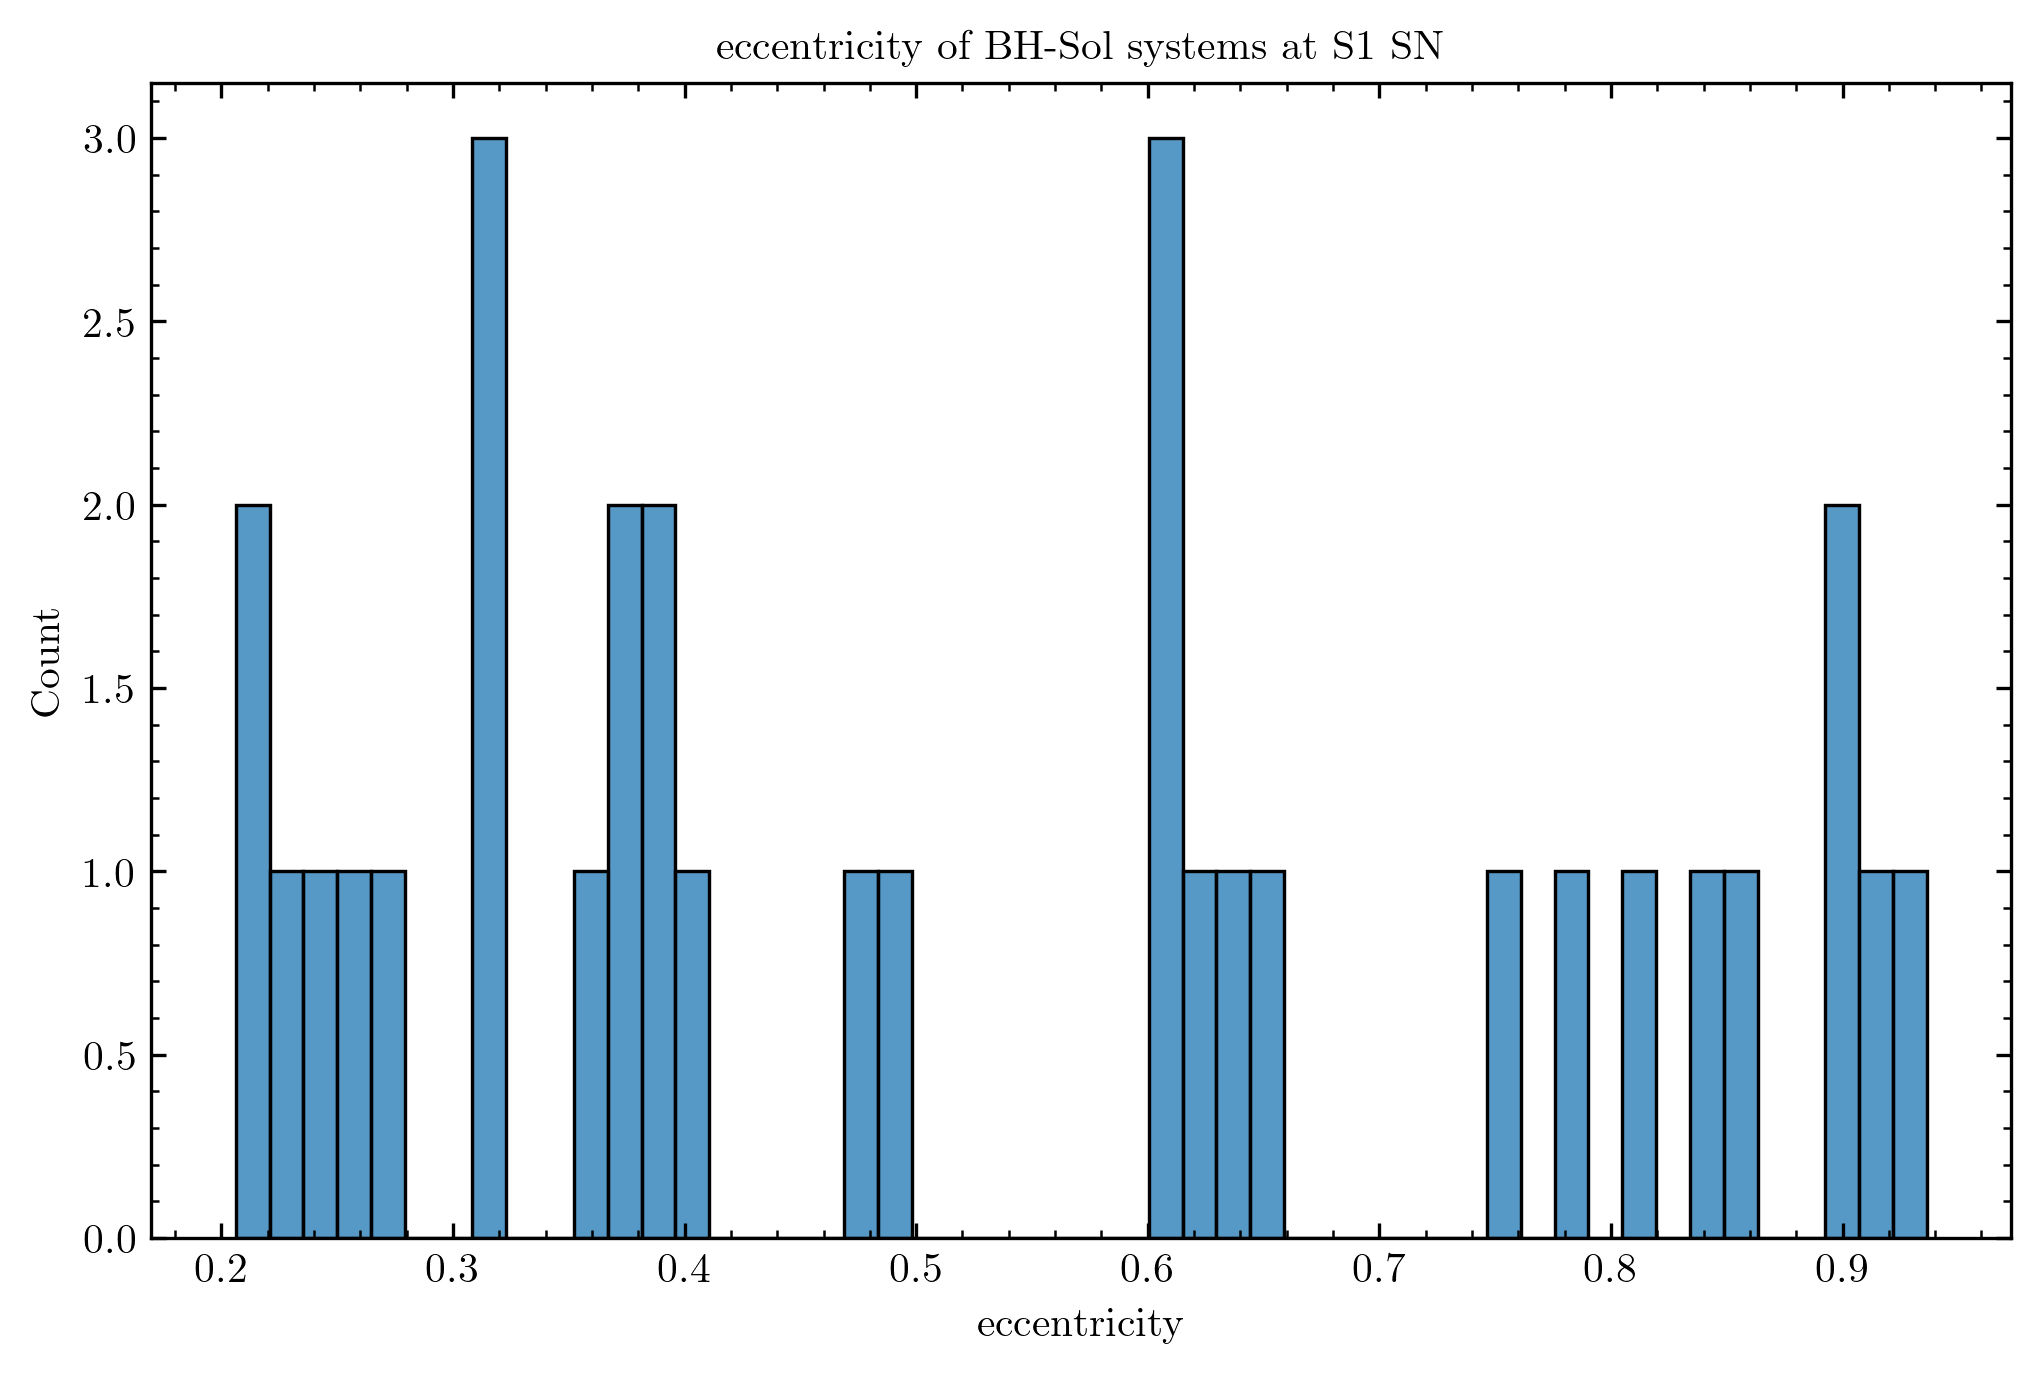

In [72]:
basicColHist(bhSolRows, 'eccentricity')

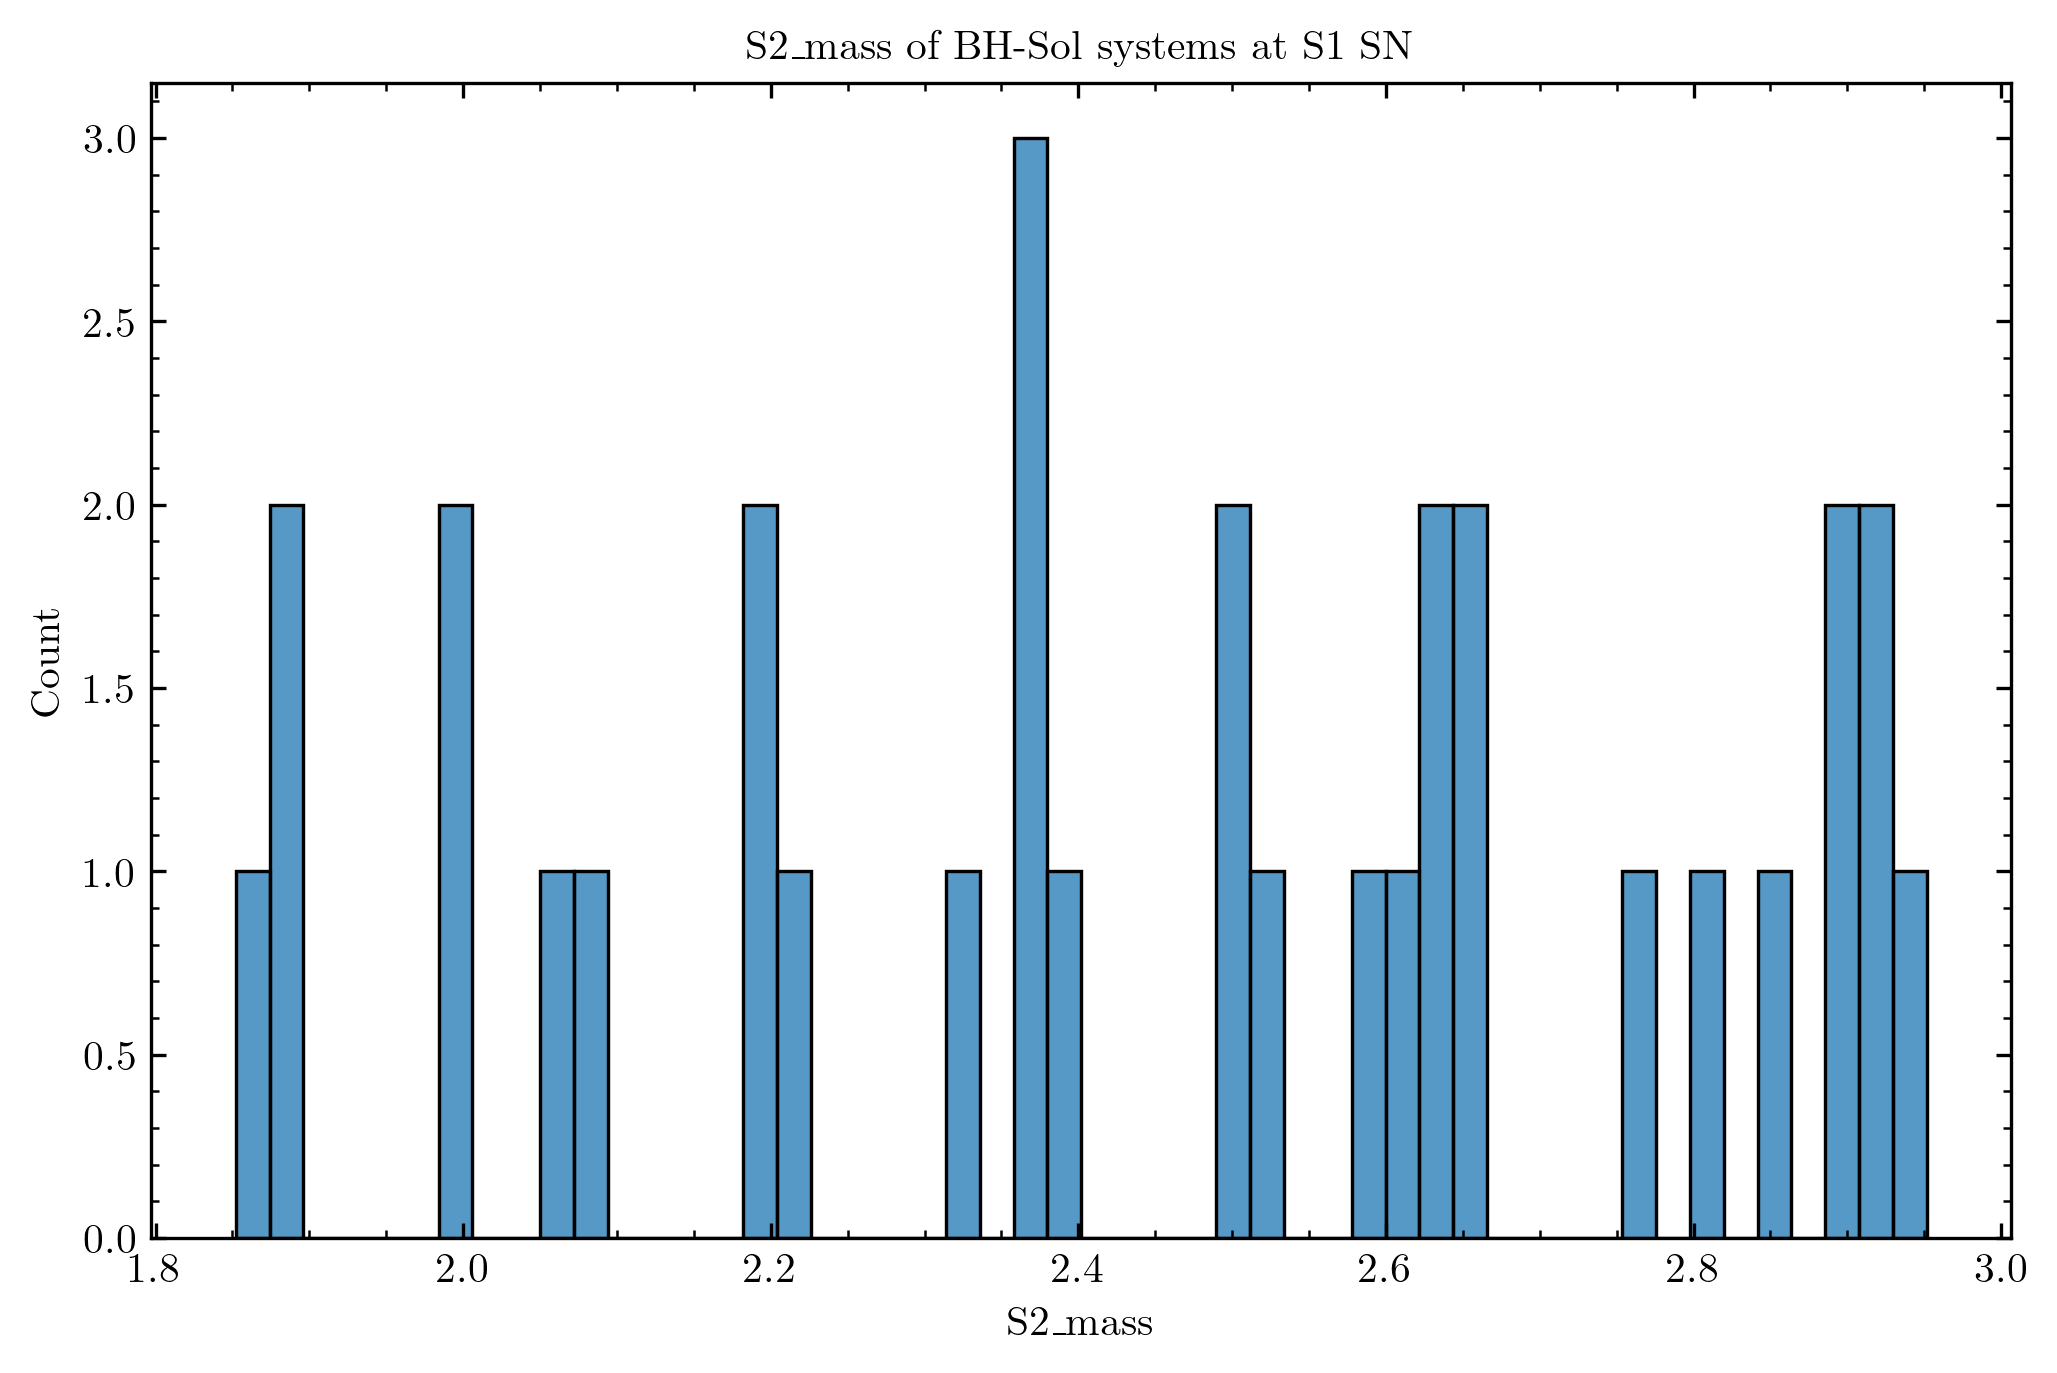

In [73]:
basicColHist(bhSolRows,'S2_mass')

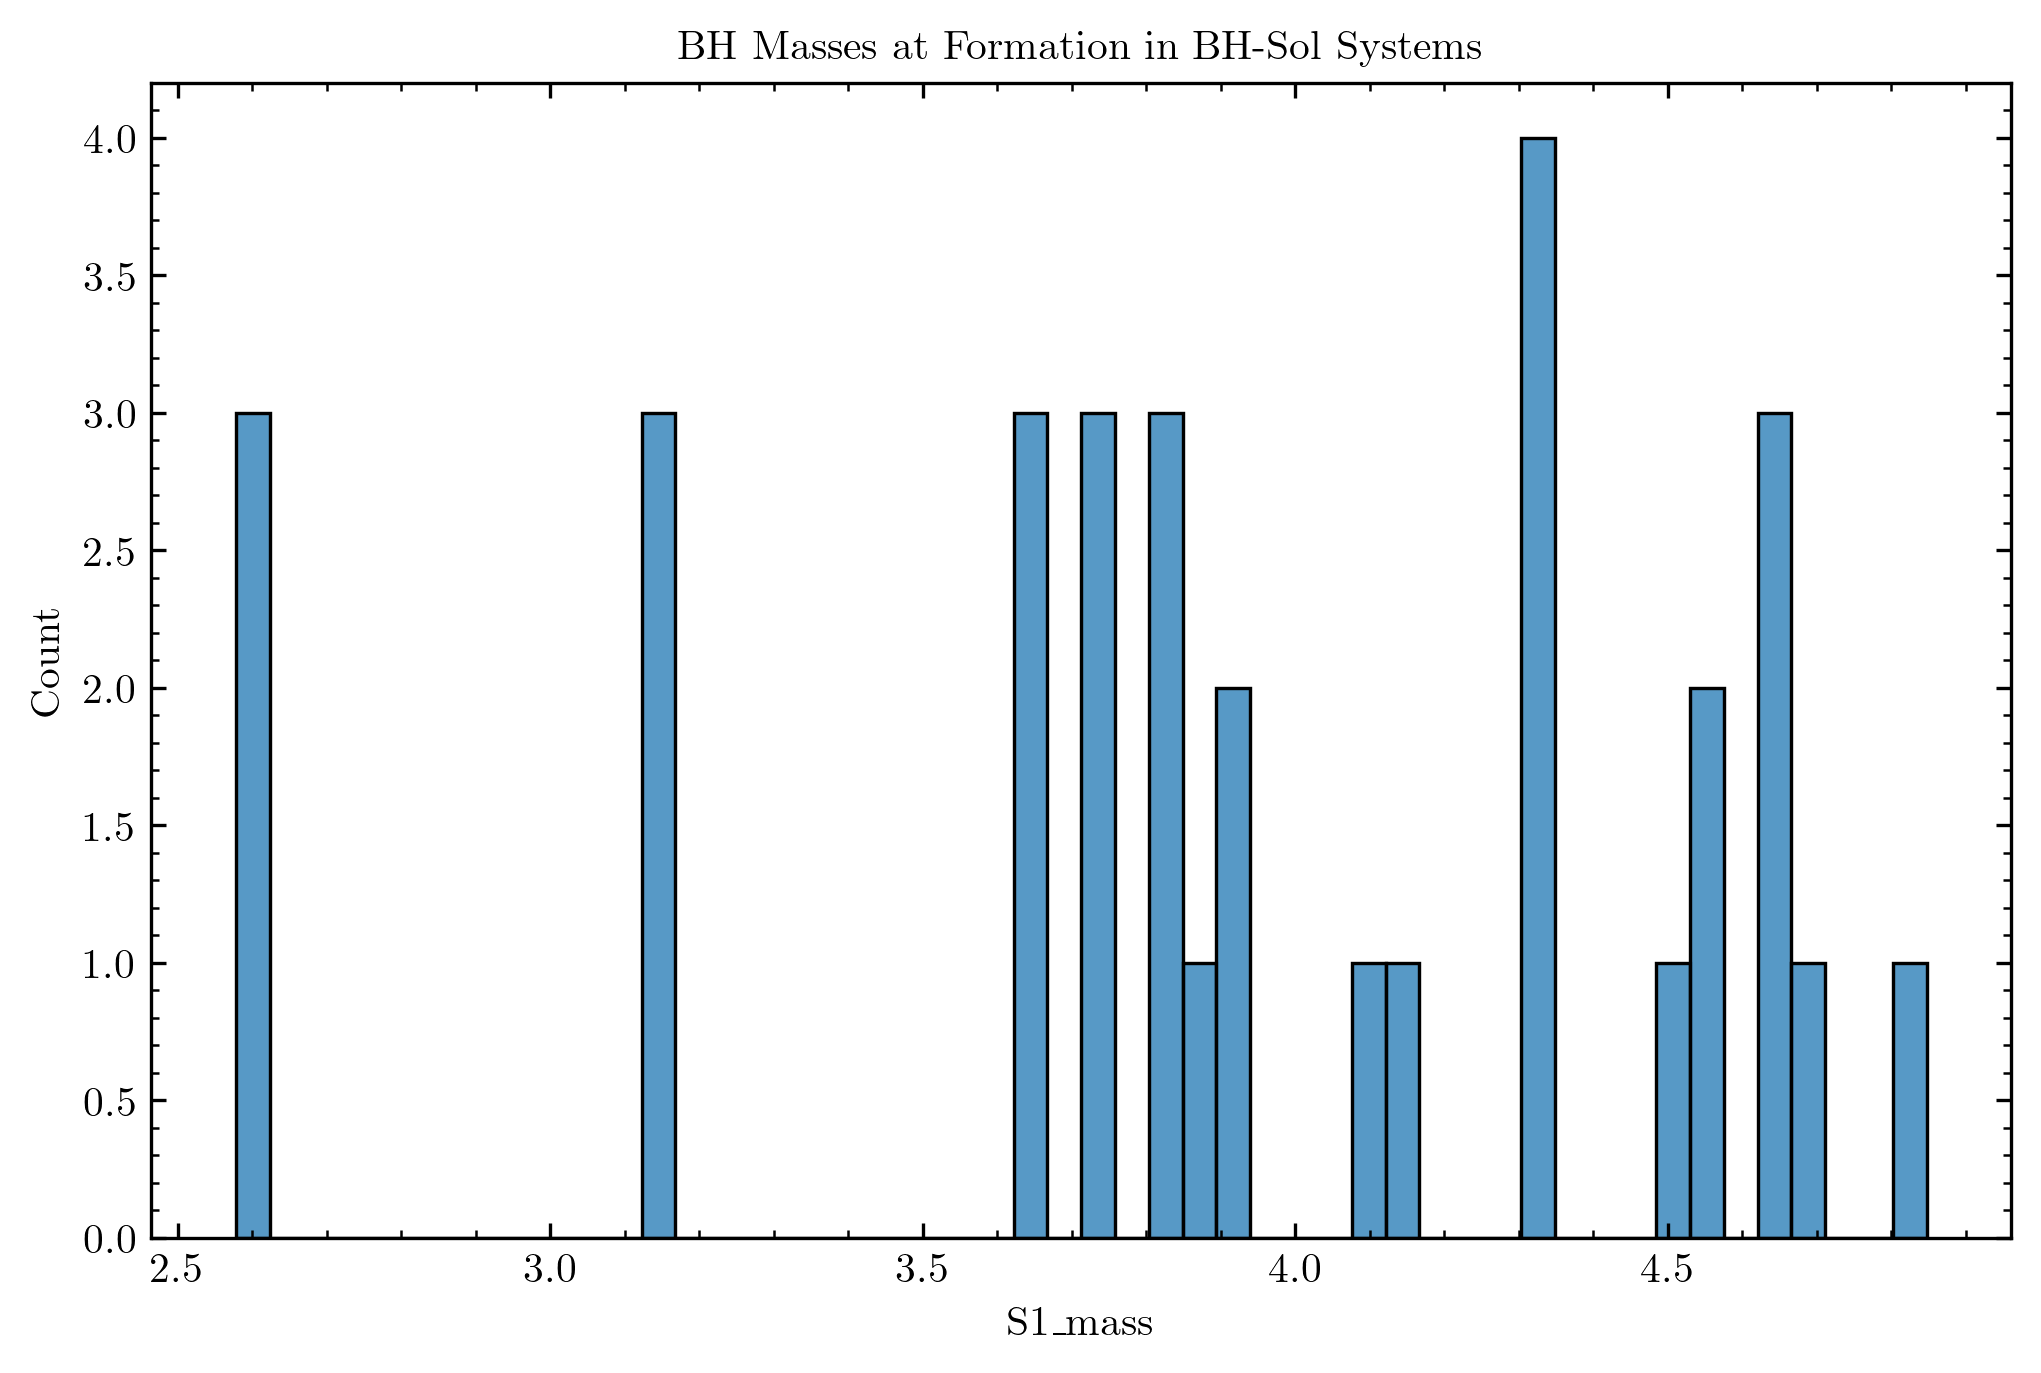

In [74]:
basicColHist(bhSolRows,'S1_mass', title='BH Masses at Formation in BH-Sol Systems')

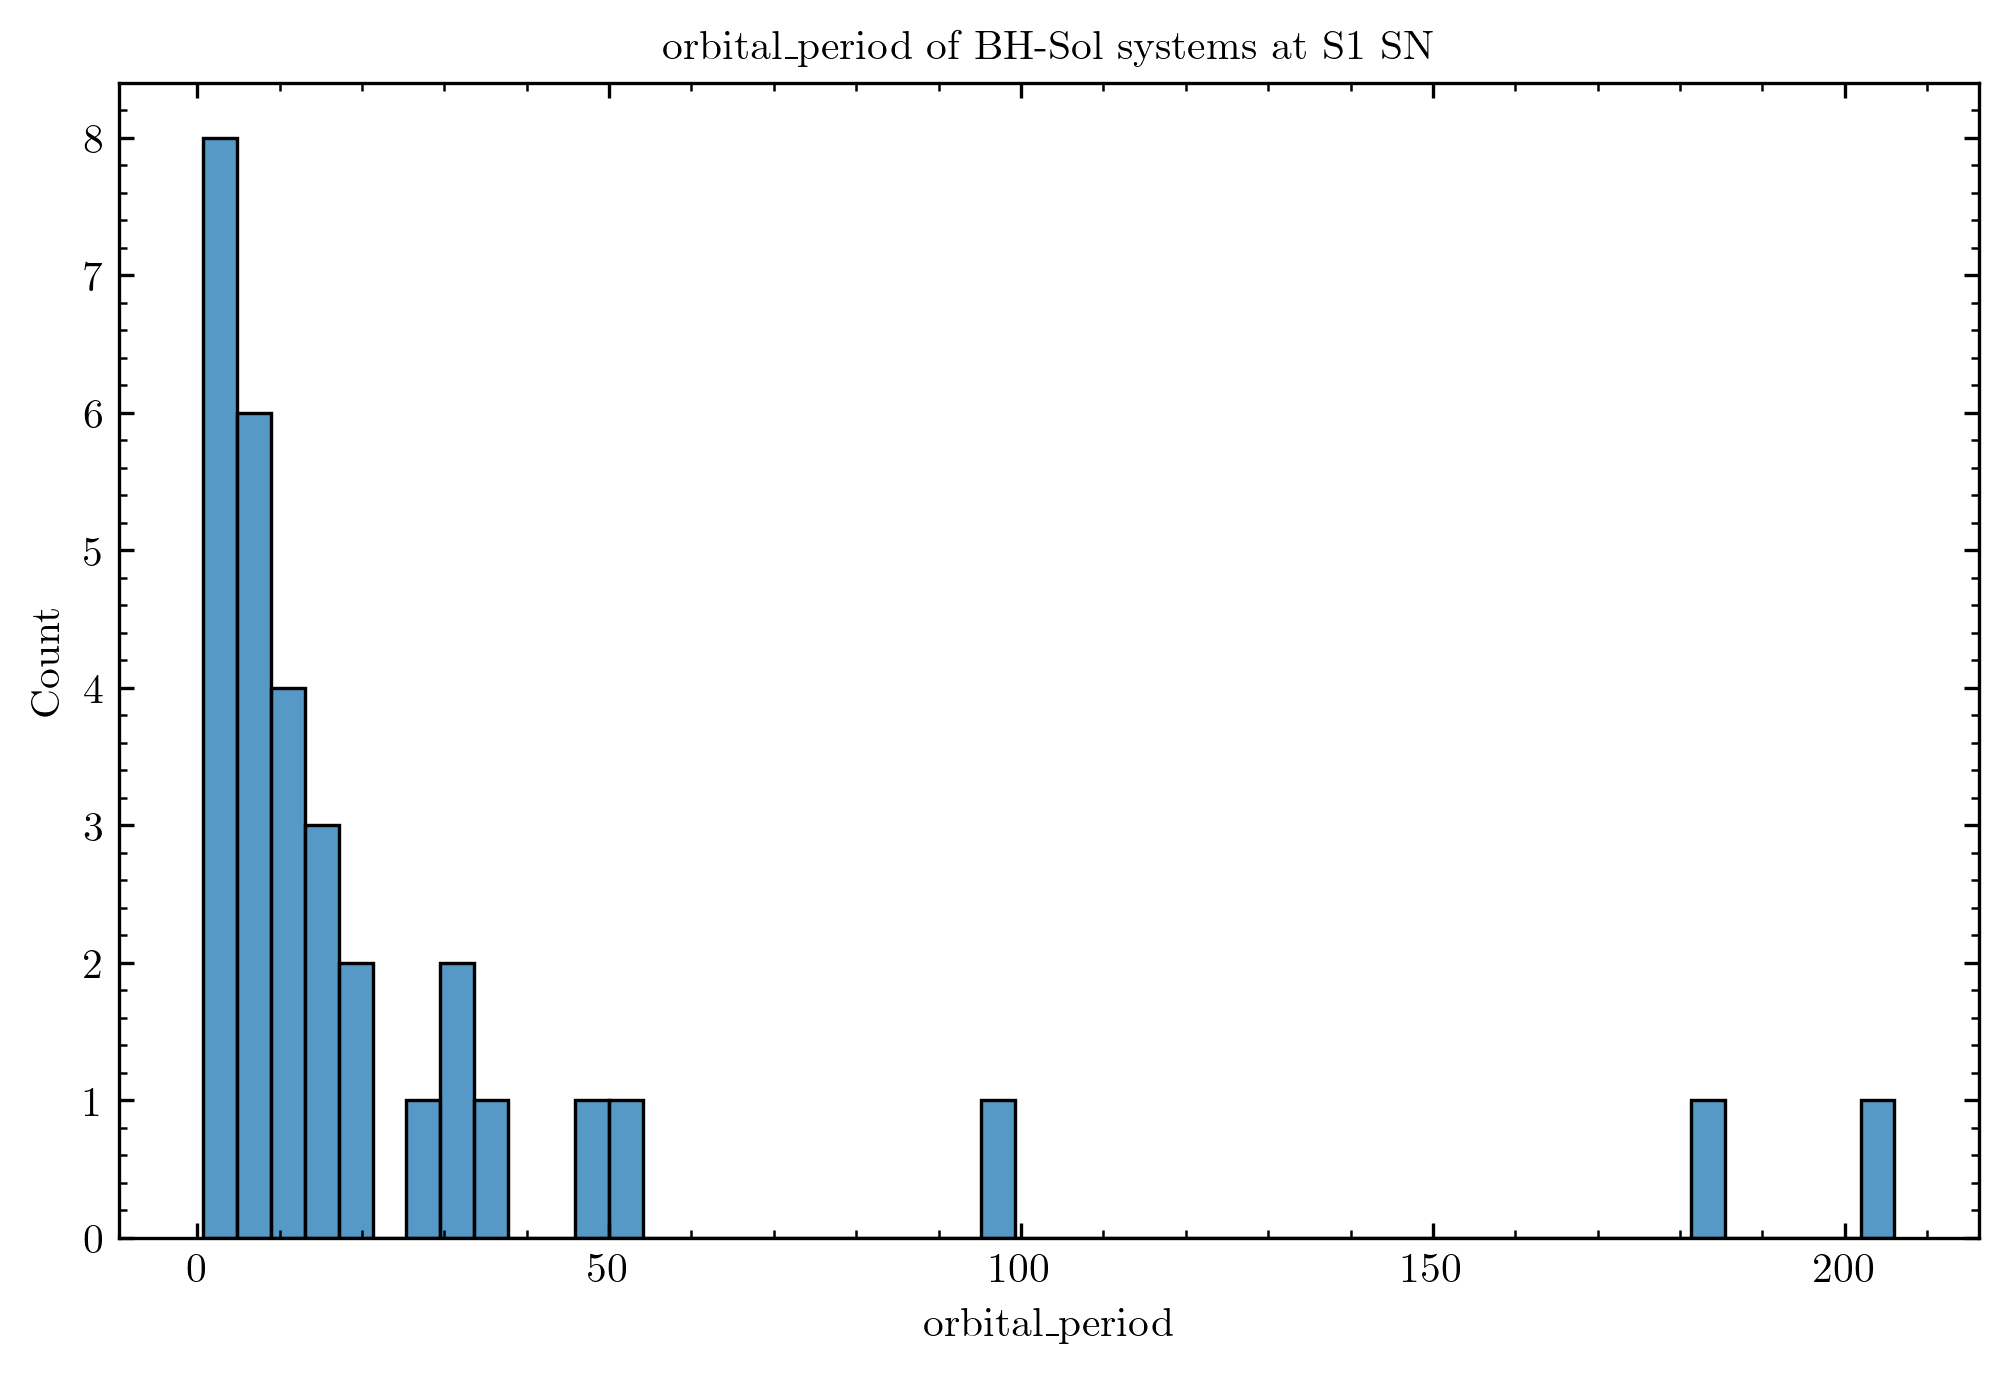

In [75]:
basicColHist(bhSolRows,'orbital_period', saveFig=True, savePath=graphSave)

In [76]:
slimOP = bhSolRows[bhSolRows['orbital_period'] < 25]['orbital_period']

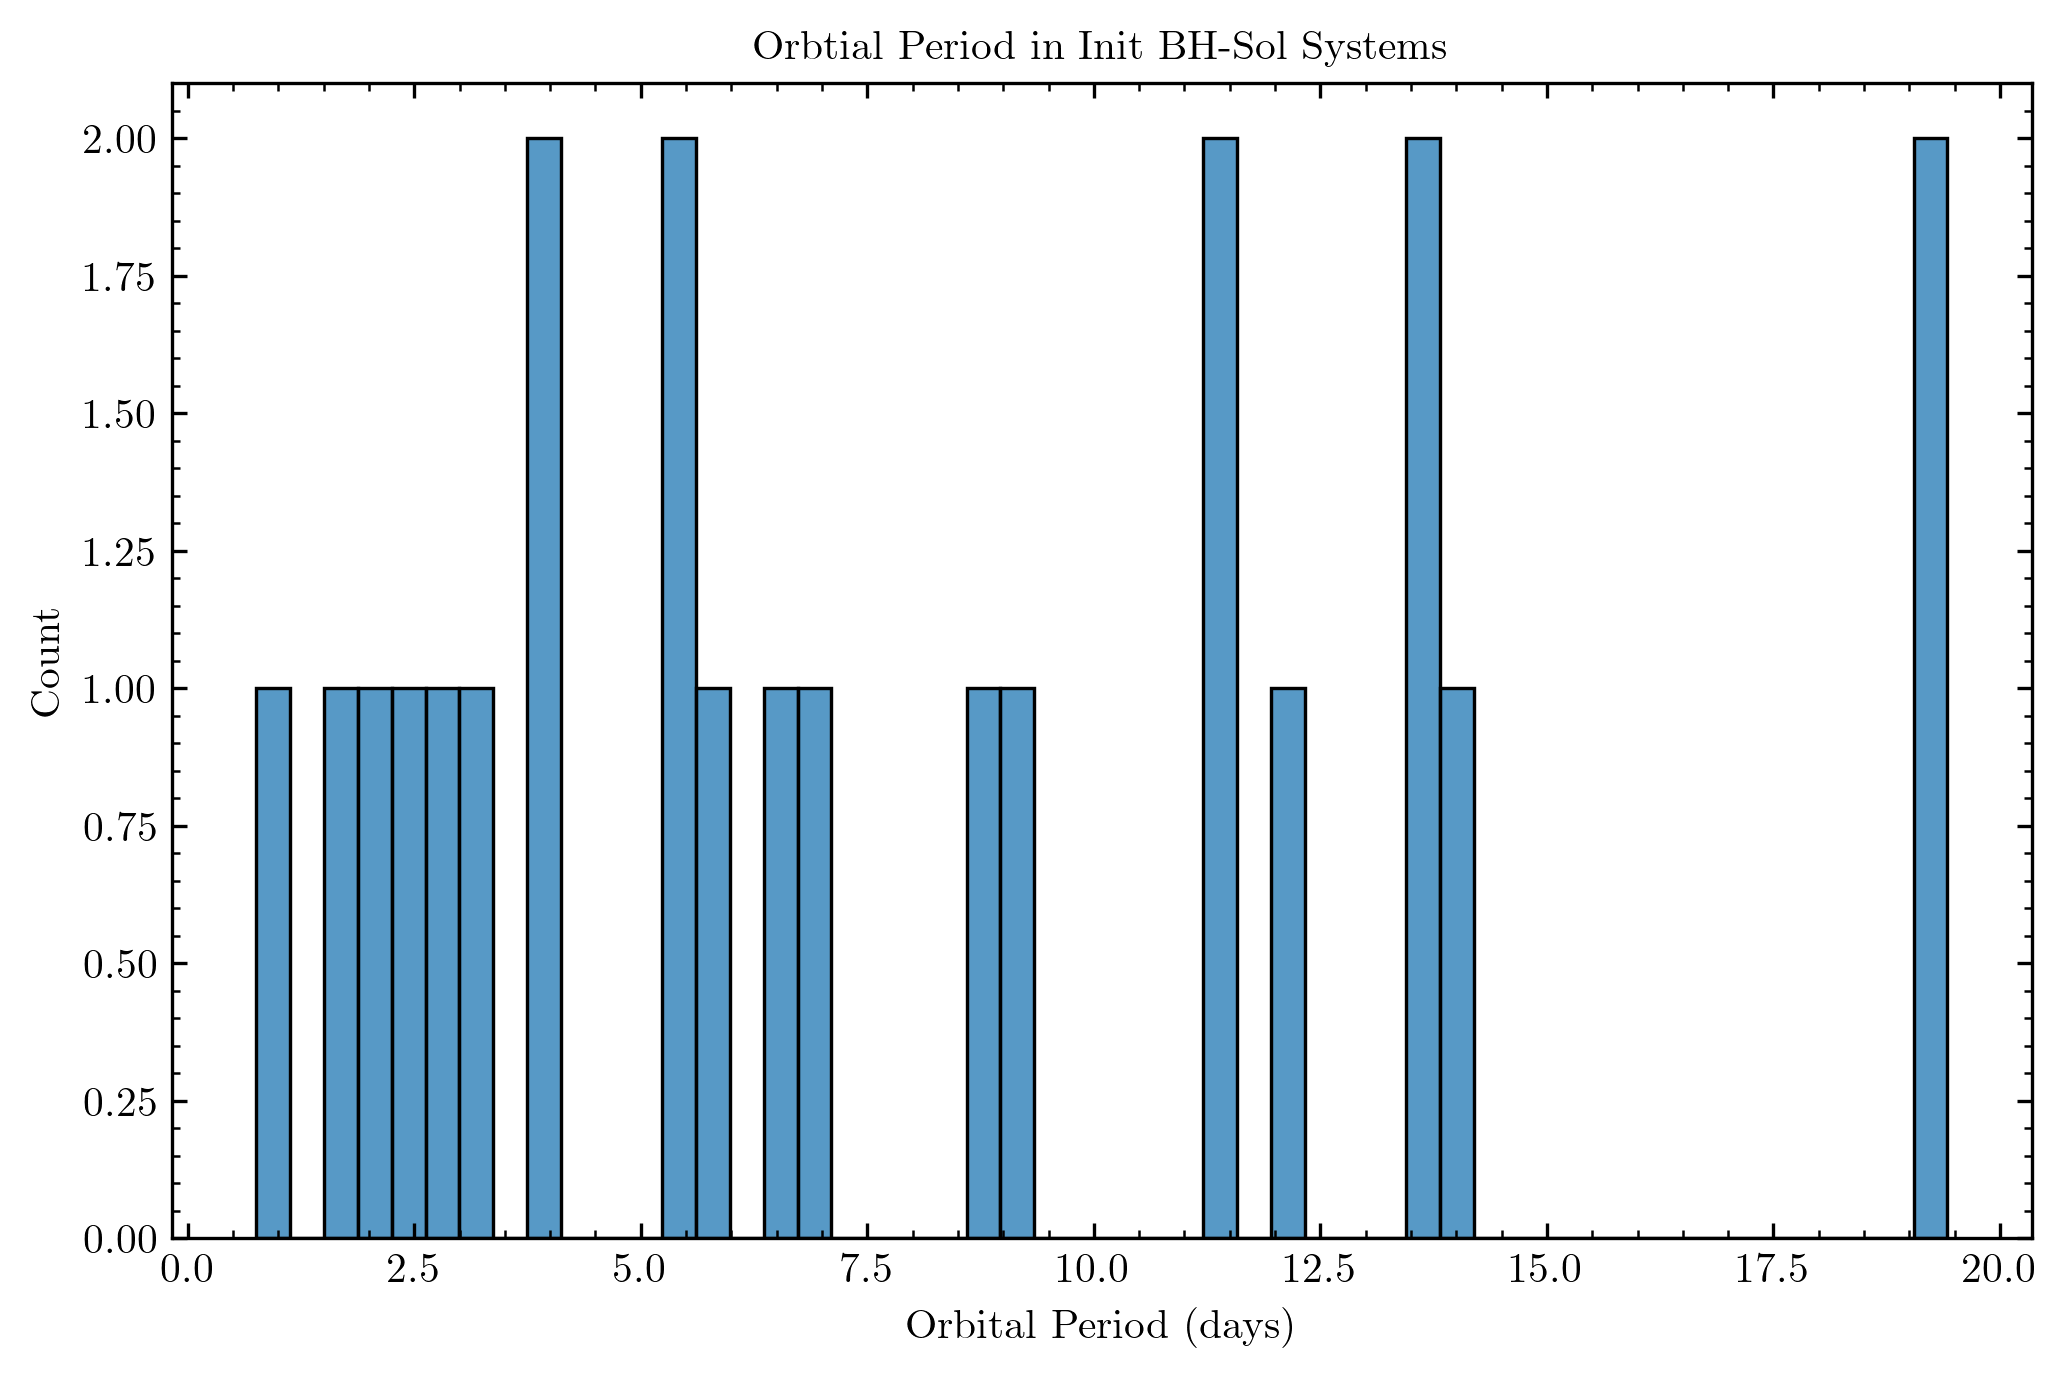

In [77]:
genVarHist(slimOP, title='Orbtial Period in Init BH-Sol Systems', xLabel='Orbital Period (days)', saveFig=True, savePath=graphSave)

In [78]:
# HR_Diagram(bhSolRows,
#            'BhSol',
#            Star_Radius=15)

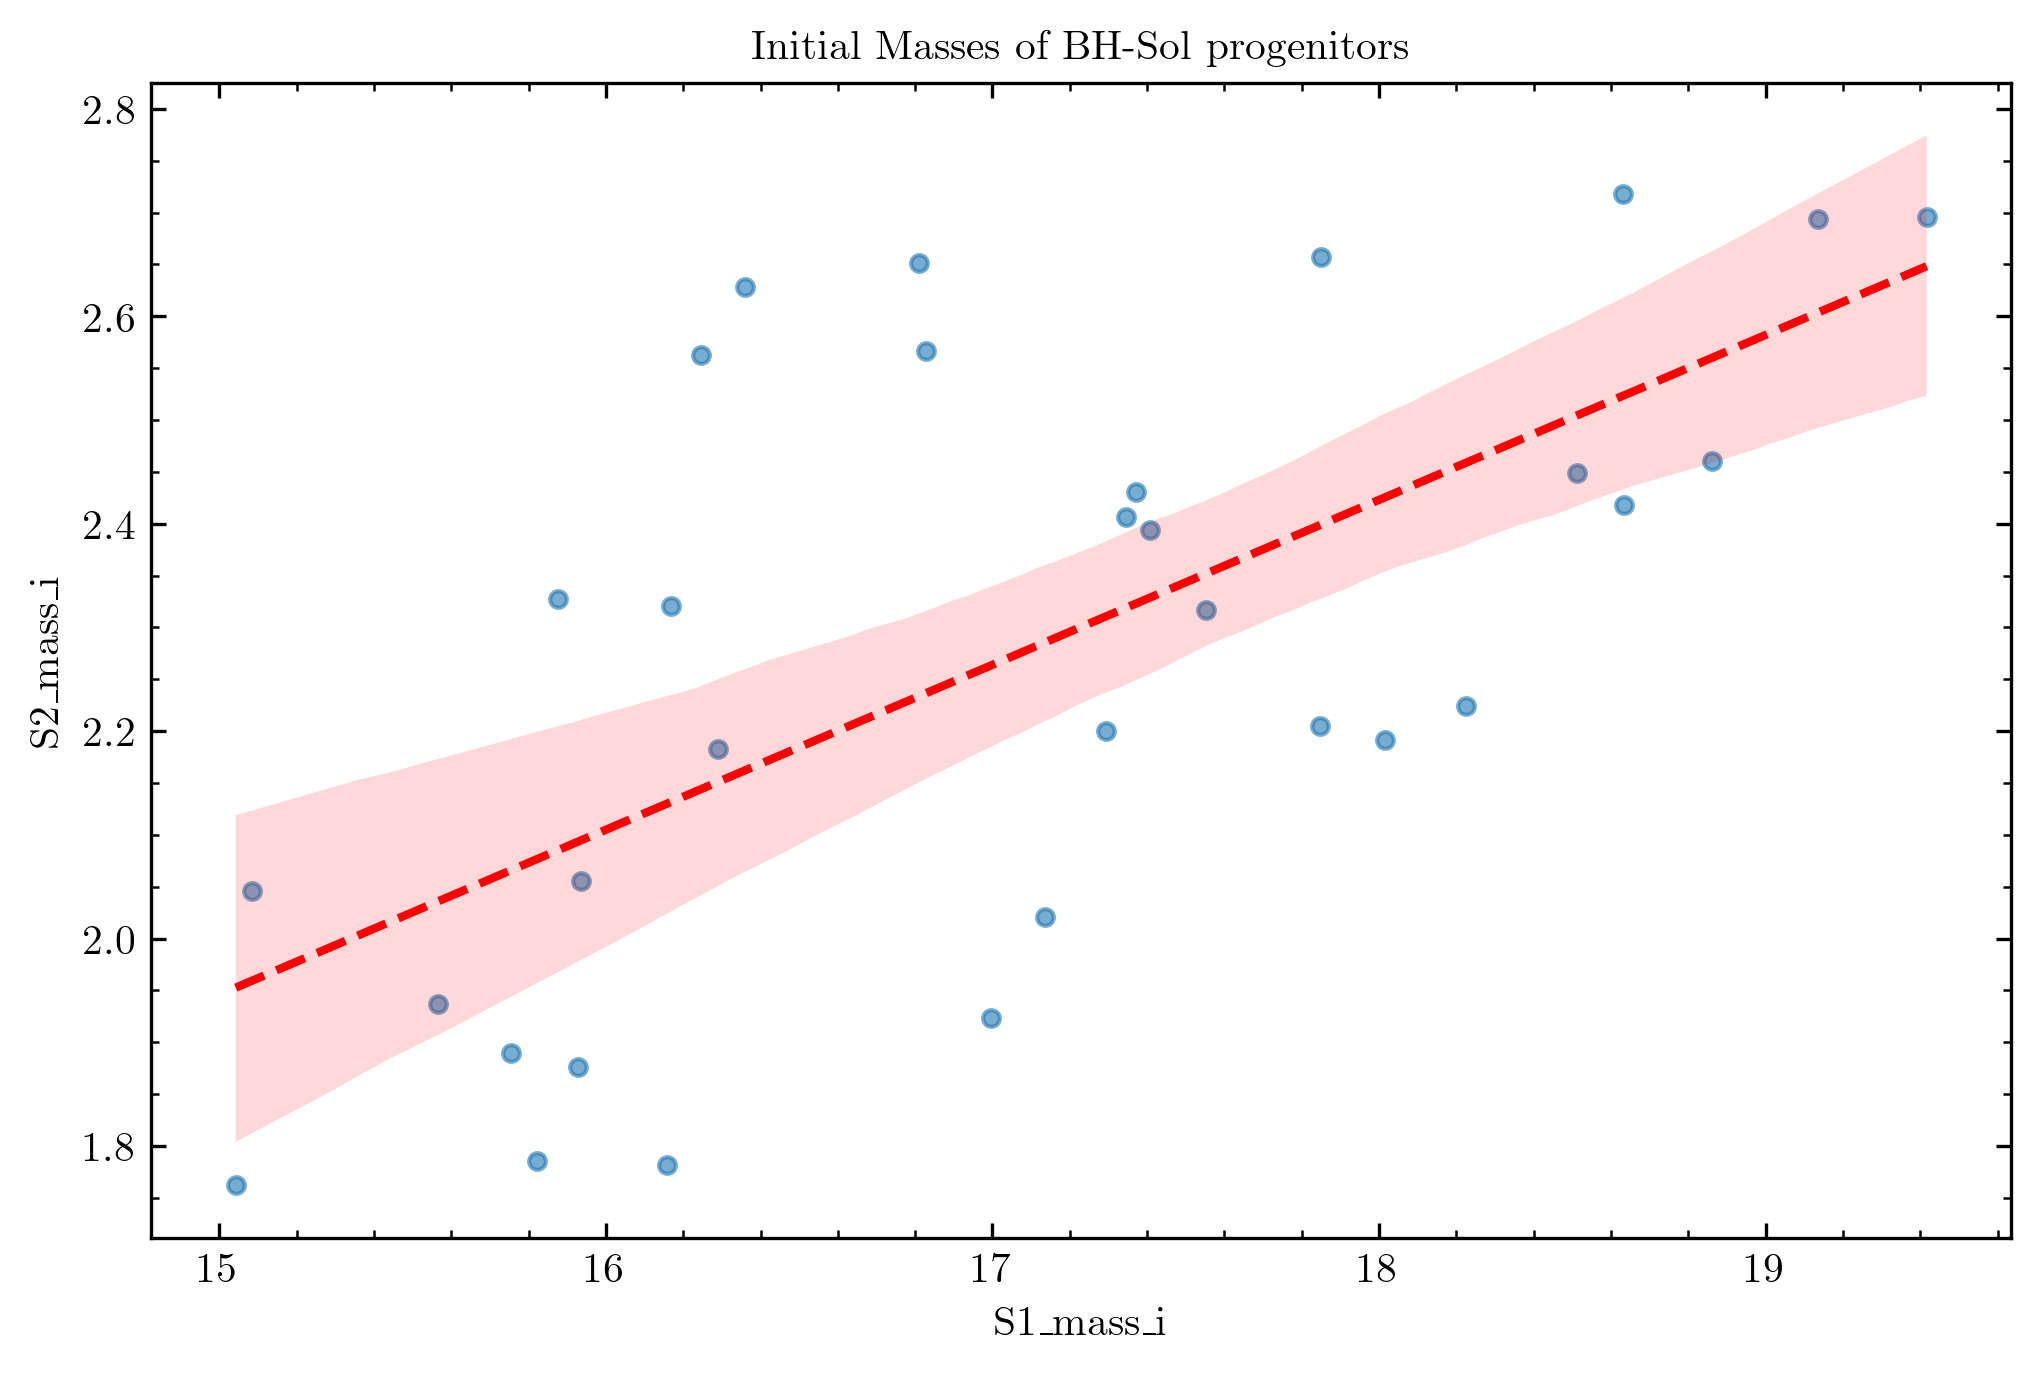

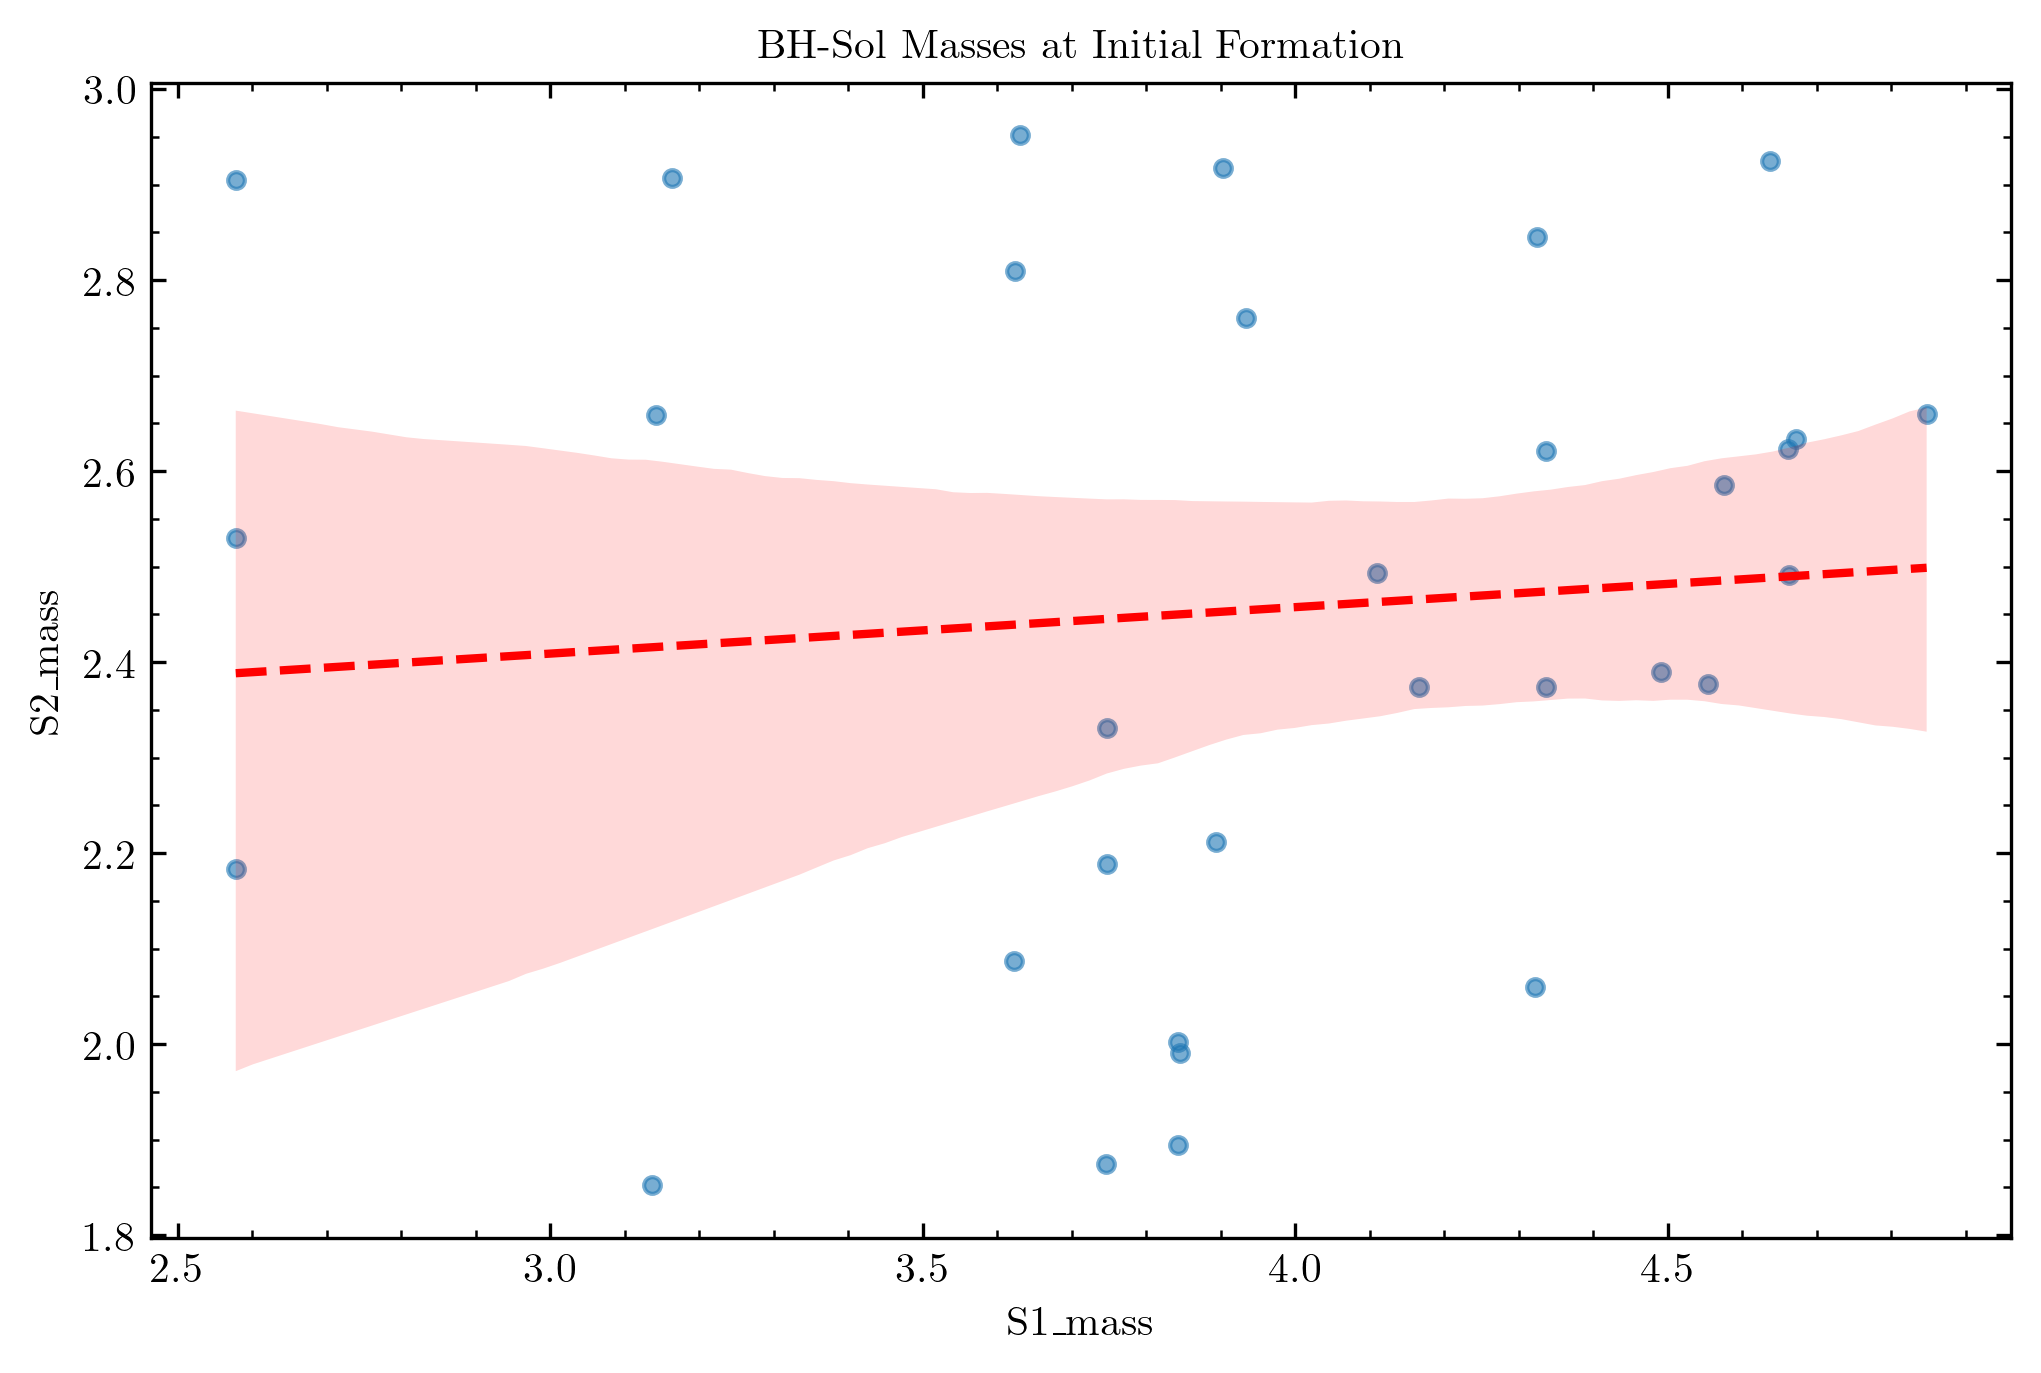

In [79]:
xVsY(df = pOneline, xvar= 'S1_mass_i', yvar='S2_mass_i', title='Initial Masses of BH-Sol progenitors', fit=True, saveFig=False, savePath=graphSave)

xVsY(df = bhSolRows, xvar= 'S1_mass', yvar='S2_mass', title='BH-Sol Masses at Initial Formation', fit=True, saveFig=False, savePath=graphSave)

In [80]:
len(bhSolRows)

32

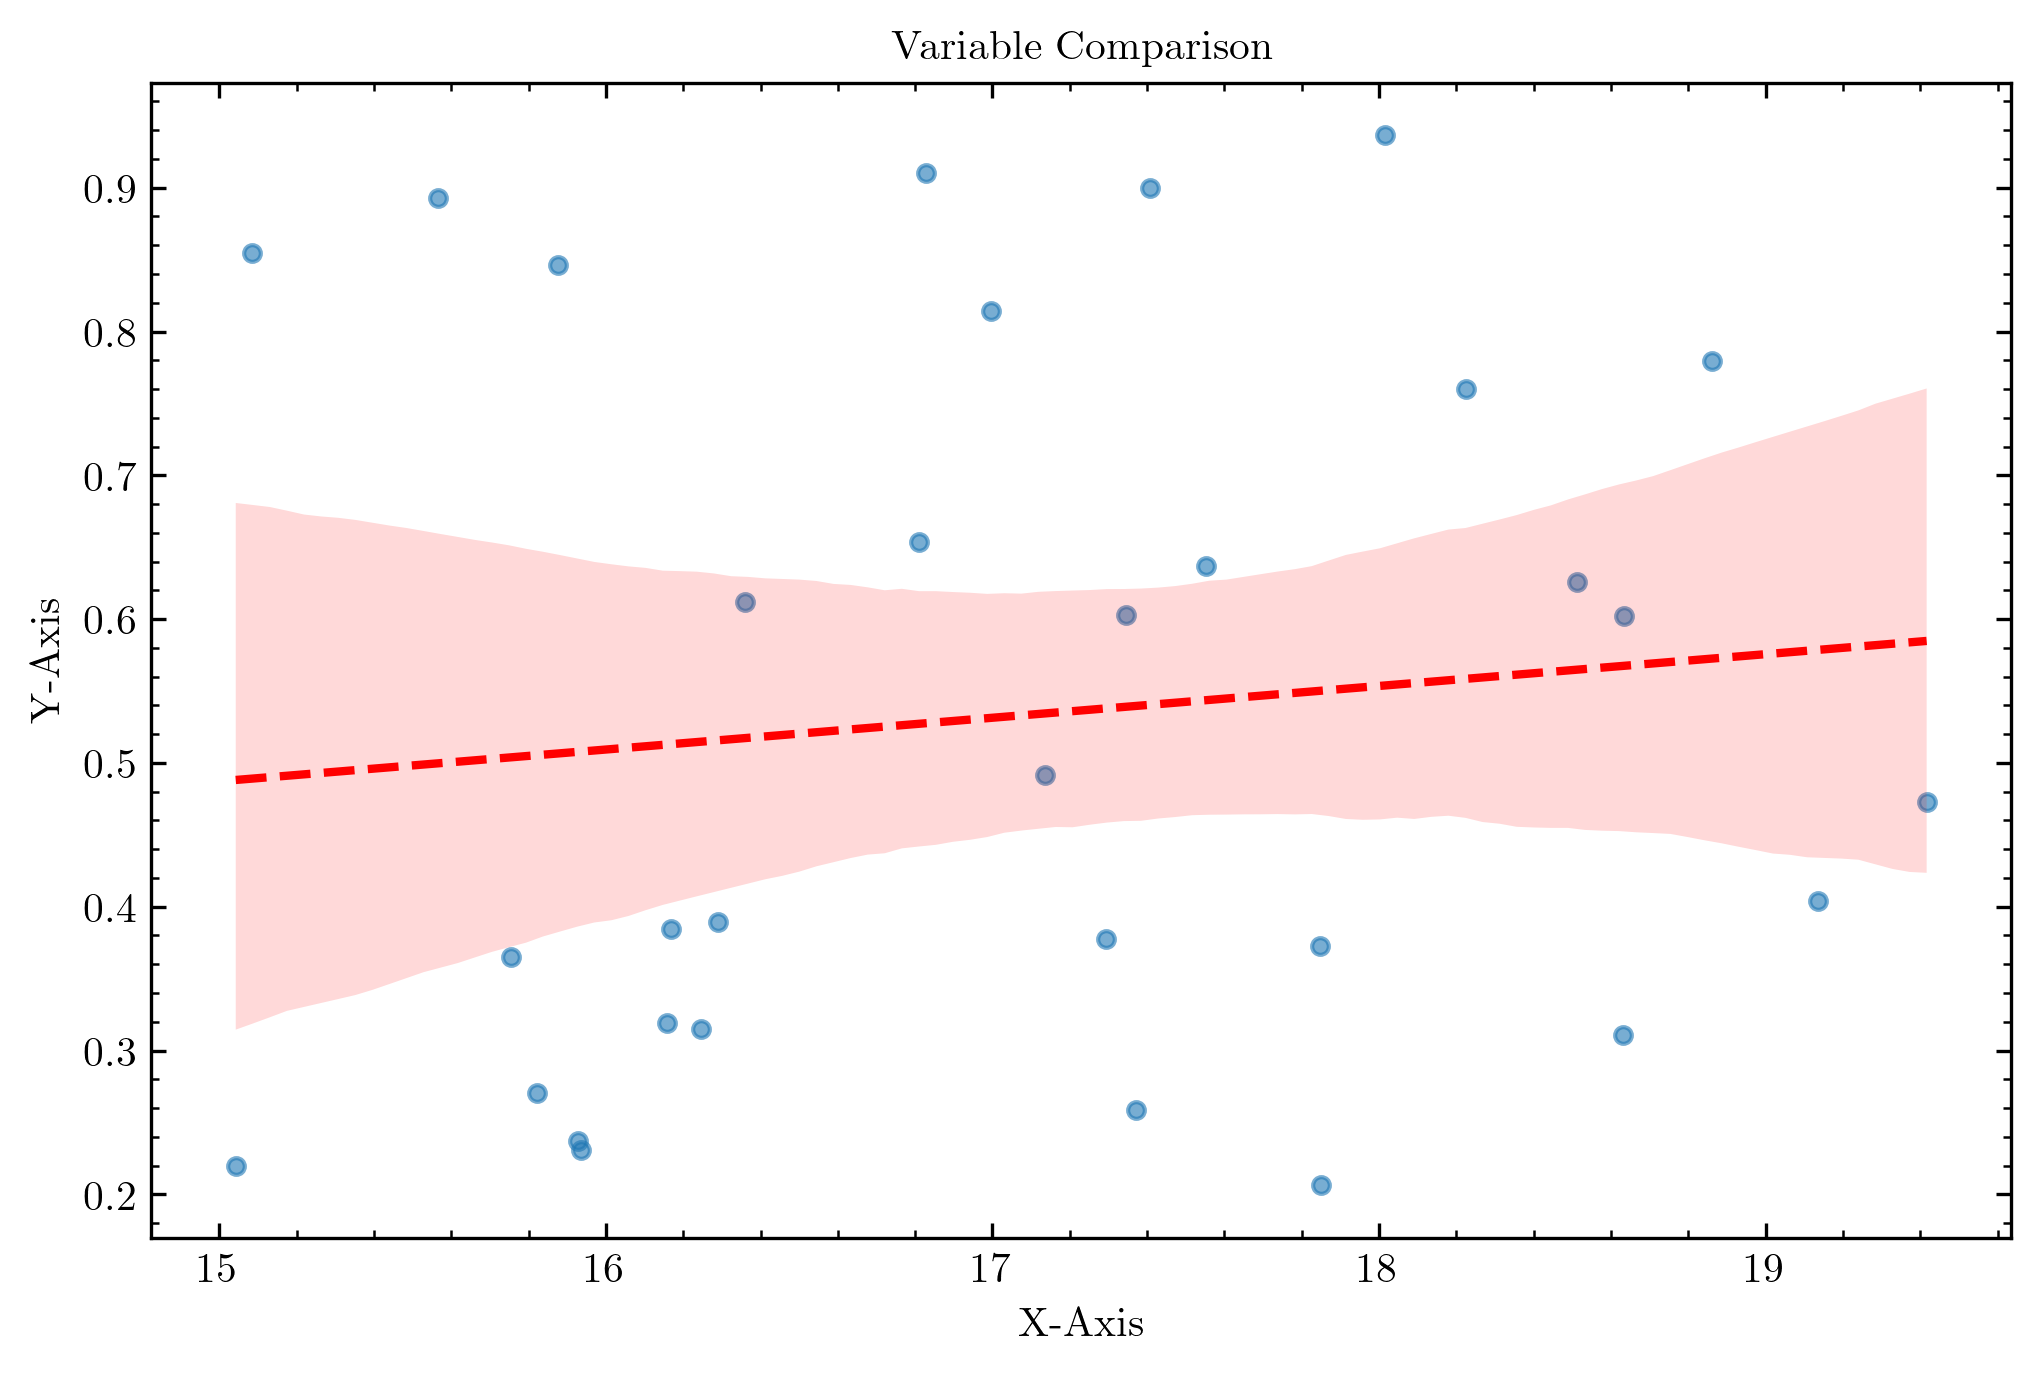

In [81]:
xVsY(useDF=False, xvar=pOneline['S1_mass_i'], yvar=bhSolRows['eccentricity'], fit=True)

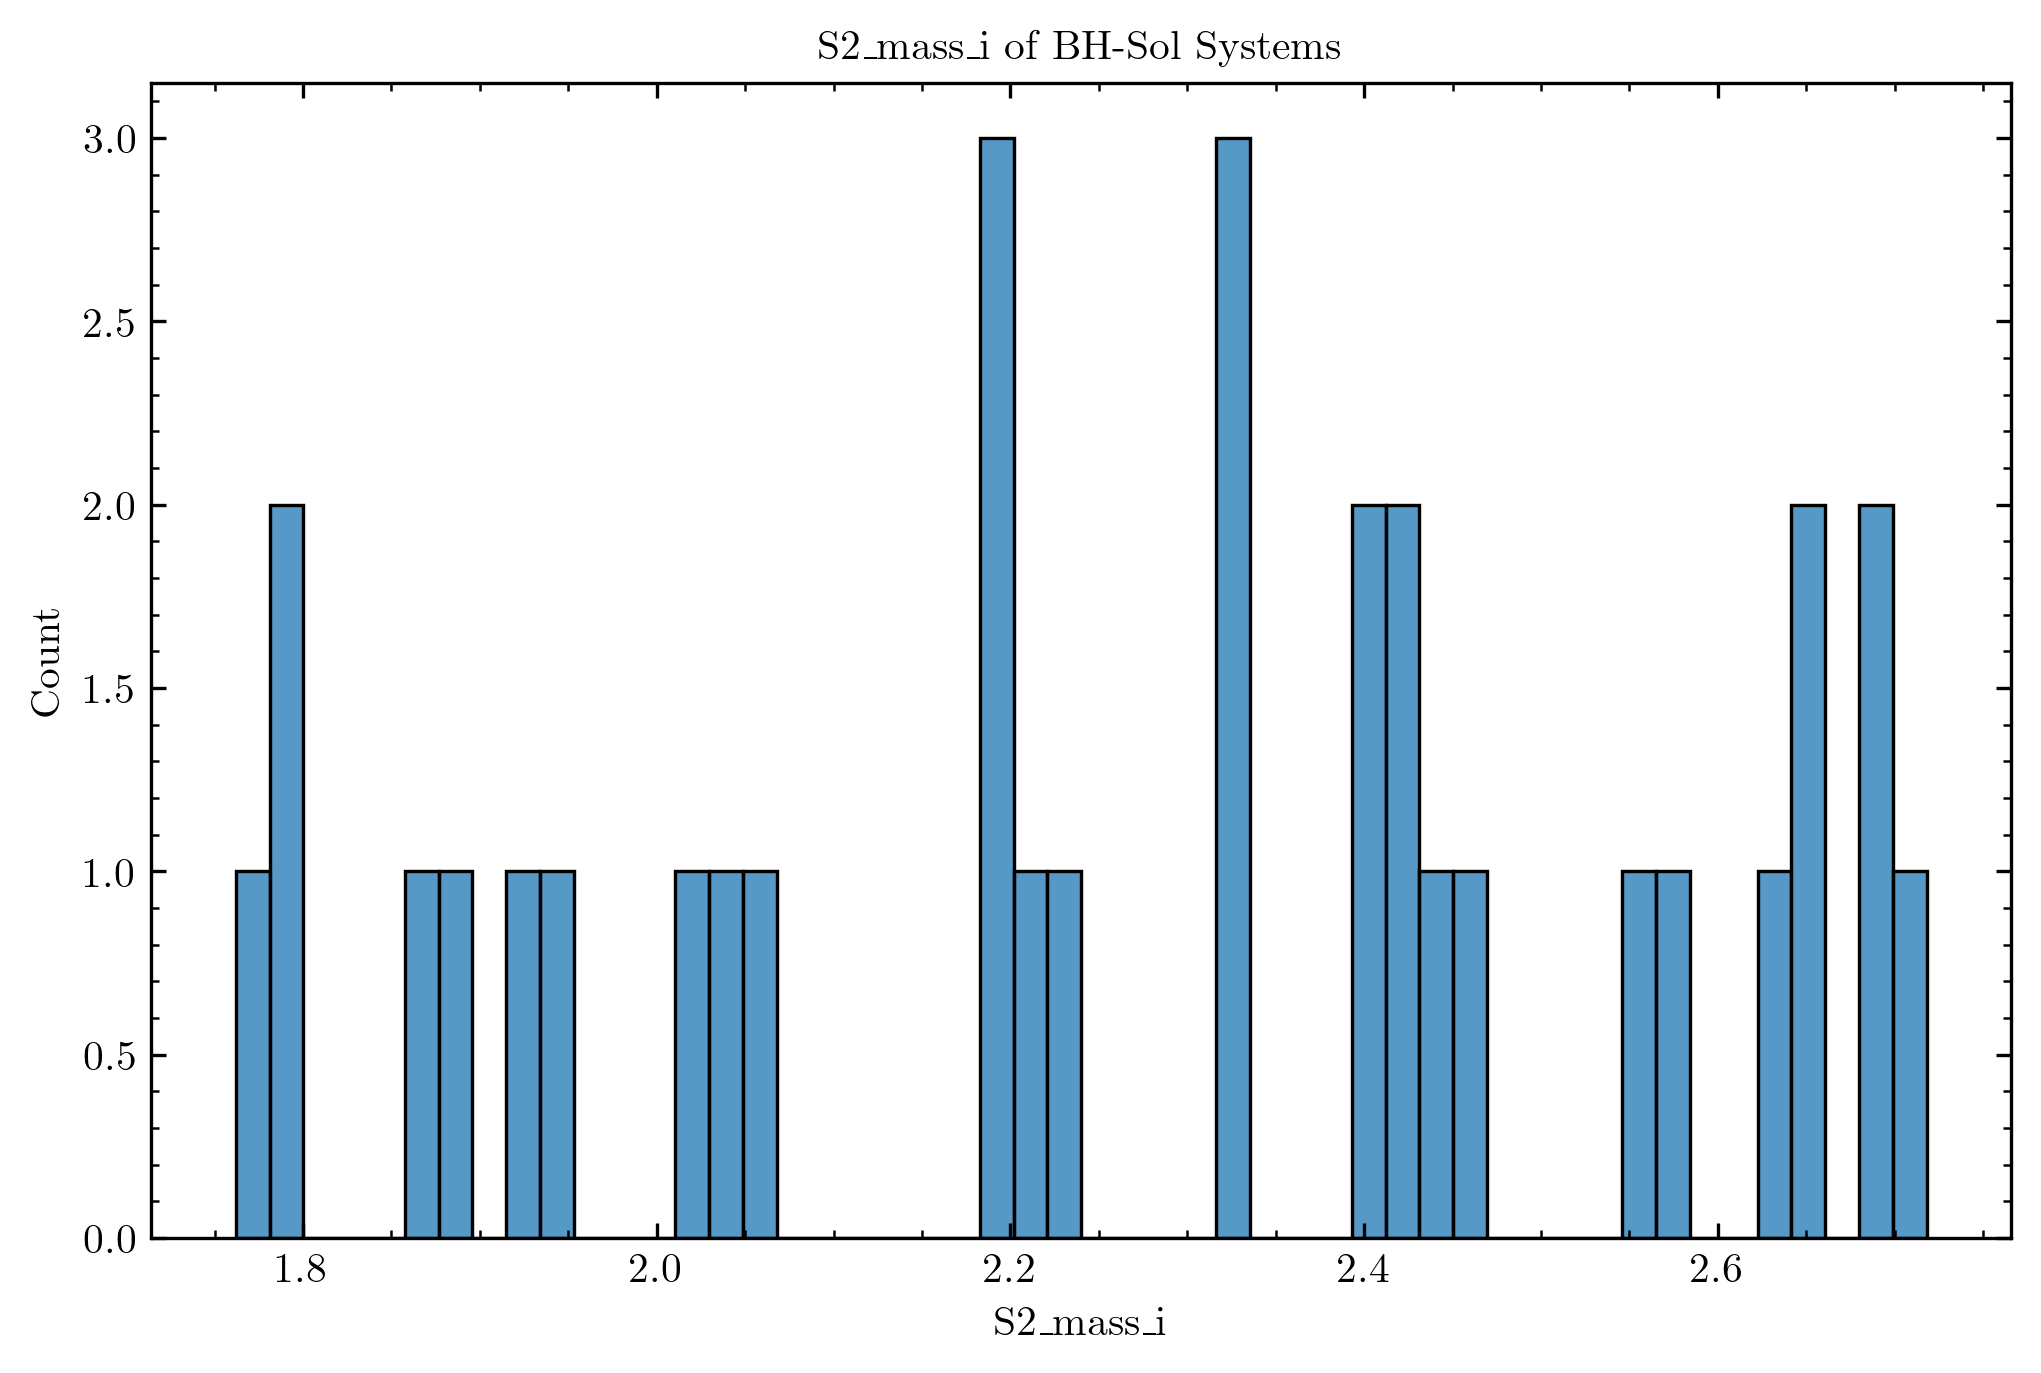

In [82]:
fig, ax = plt.subplots(figsize=(8,5))

var = 'S2_mass_i'
sns.histplot(pOneline[var], bins=50, ax=ax)

title = f'{var} of BH-Sol Systems'

ax.set_title(title)
ax.set_xlabel(var)
ax.set_ylabel('Count')

clean_name = title.replace(' ', '_').replace('/', '-') + '.pgf'
plt.savefig(graphSave / clean_name, bbox_inches='tight')

plt.show()

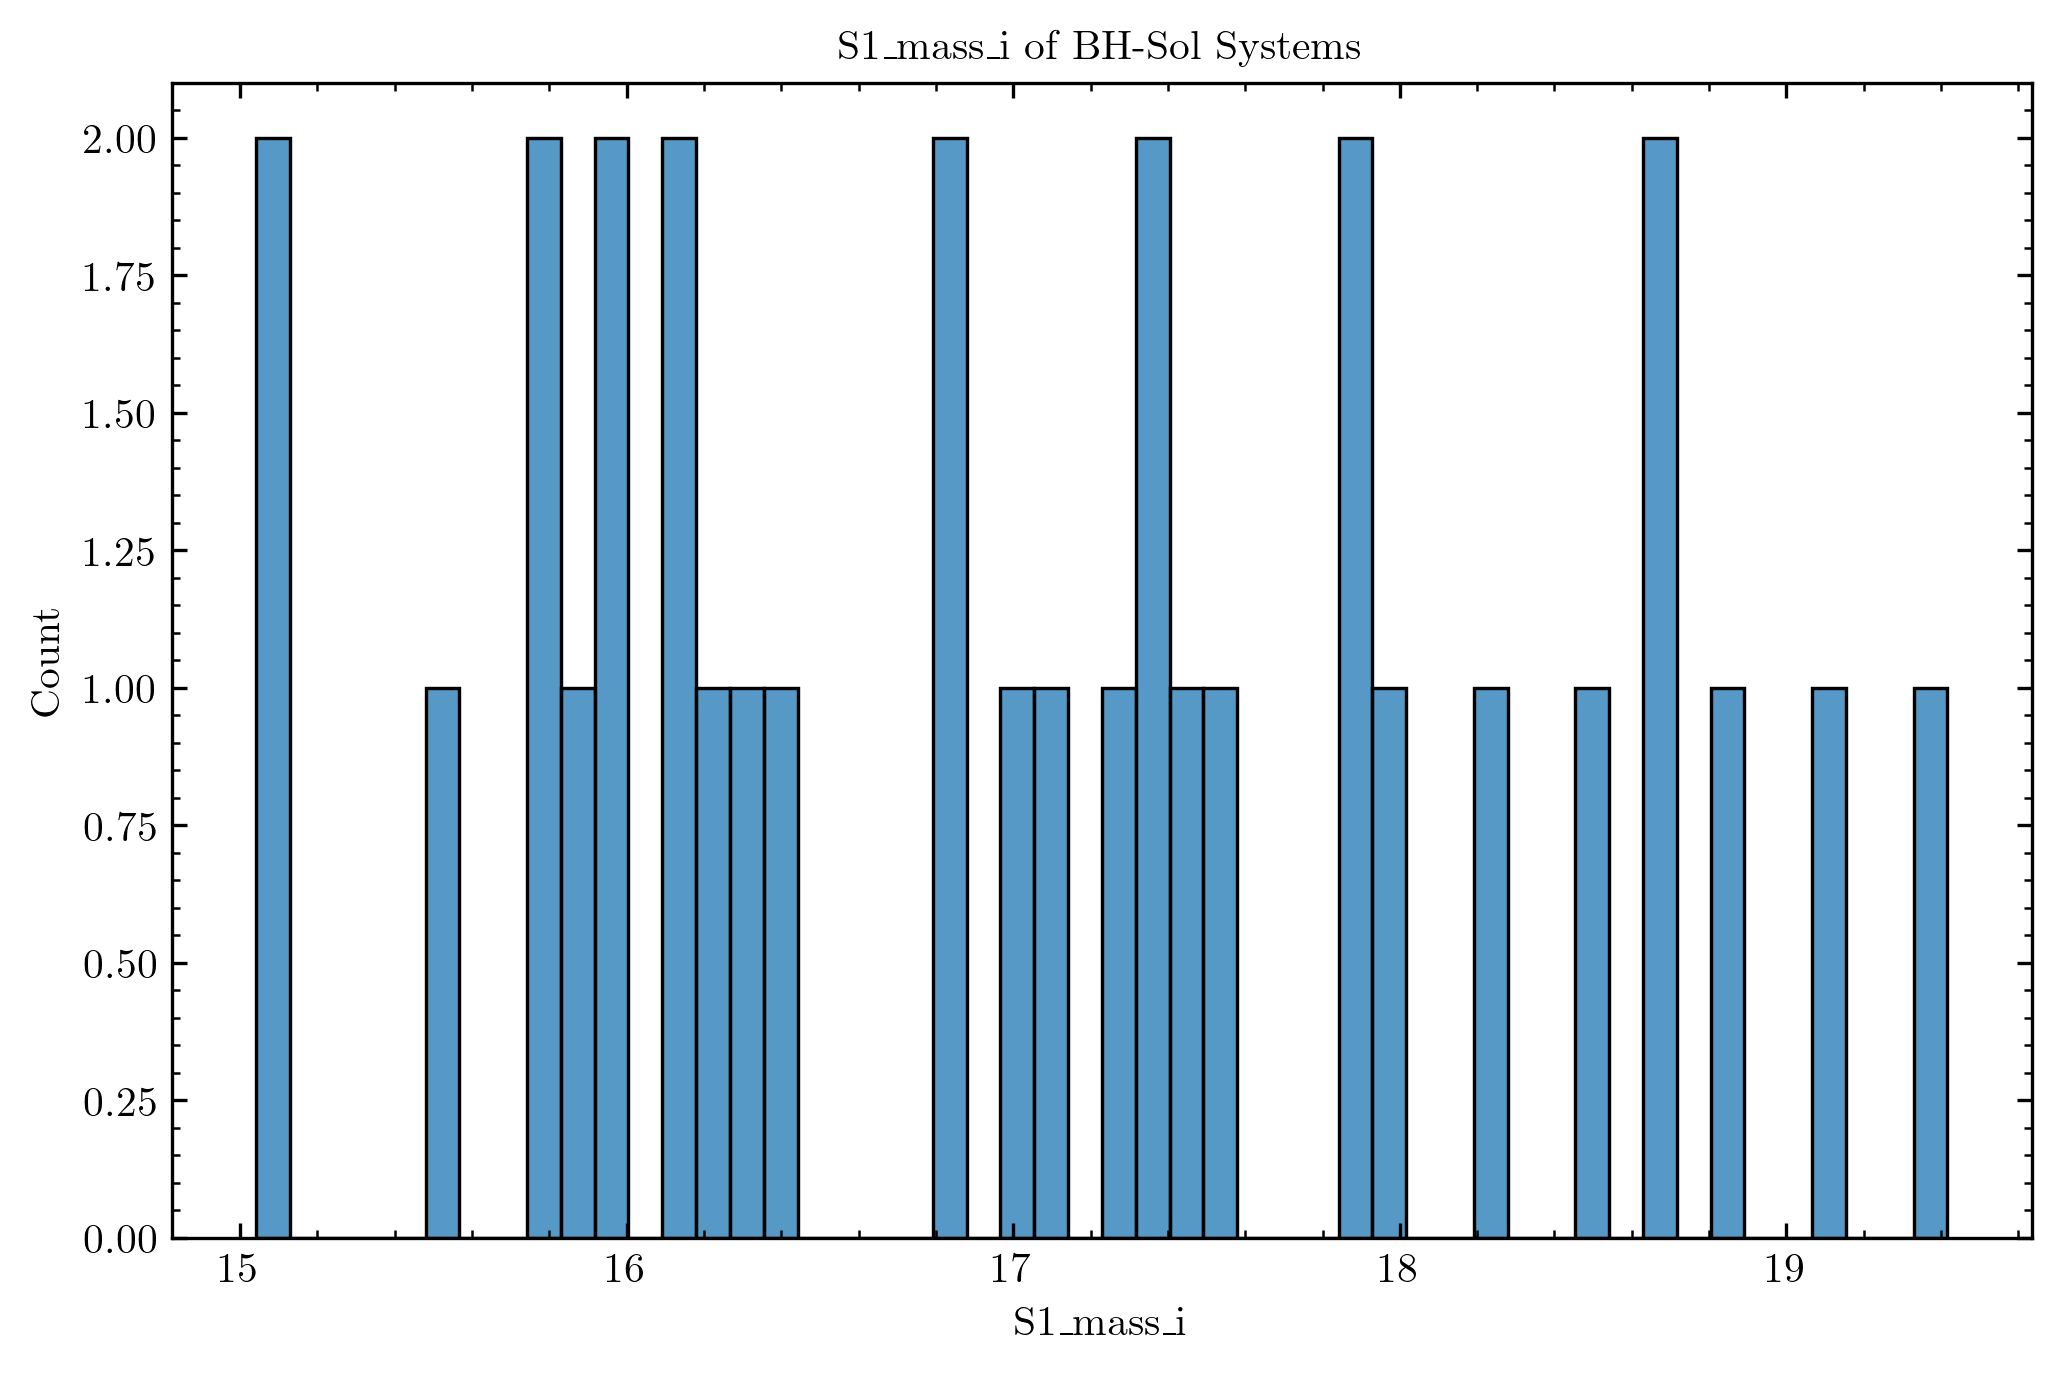

In [83]:
fig, ax = plt.subplots(figsize=(8,5))

var = 'S1_mass_i'
sns.histplot(pOneline[var], bins=50, ax=ax)

title = f'{var} of BH-Sol Systems'

ax.set_title(title)
ax.set_xlabel(var)
ax.set_ylabel('Count')

clean_name = title.replace(' ', '_').replace('/', '-') + '.pgf'
plt.savefig(graphSave / clean_name, bbox_inches='tight')

plt.show()

In [94]:
SunLike_pop = Population(str(DataPath / 'SunLikeStar_Filt' / 'BH_Sol_Filtered_1e+00_Zsun_population.h5'))
SunLike_bhSolRows = pd.read_csv(DataPath /'SunLikeStar_Filt' / 'BH_Sol_Filtered_1e+00_Zsun_population.csv')

sunlike_pOneline = SunLike_pop.oneline.select()

sunlike_pOneline = sunlike_pOneline.drop(17, axis='index') # failed sim
SunLike_bhSolRows = SunLike_bhSolRows.drop(17, axis='index') # failed sim


In [95]:
FullPop = Population('/home/bku2126/b1095/bku2126/stellarBHs/grids/g3/1e+00_Zsun_population.h5')


In [96]:
i = rand.choices(range(1, 1000000), k=1000)

In [97]:
randSamp = FullPop.oneline[i]

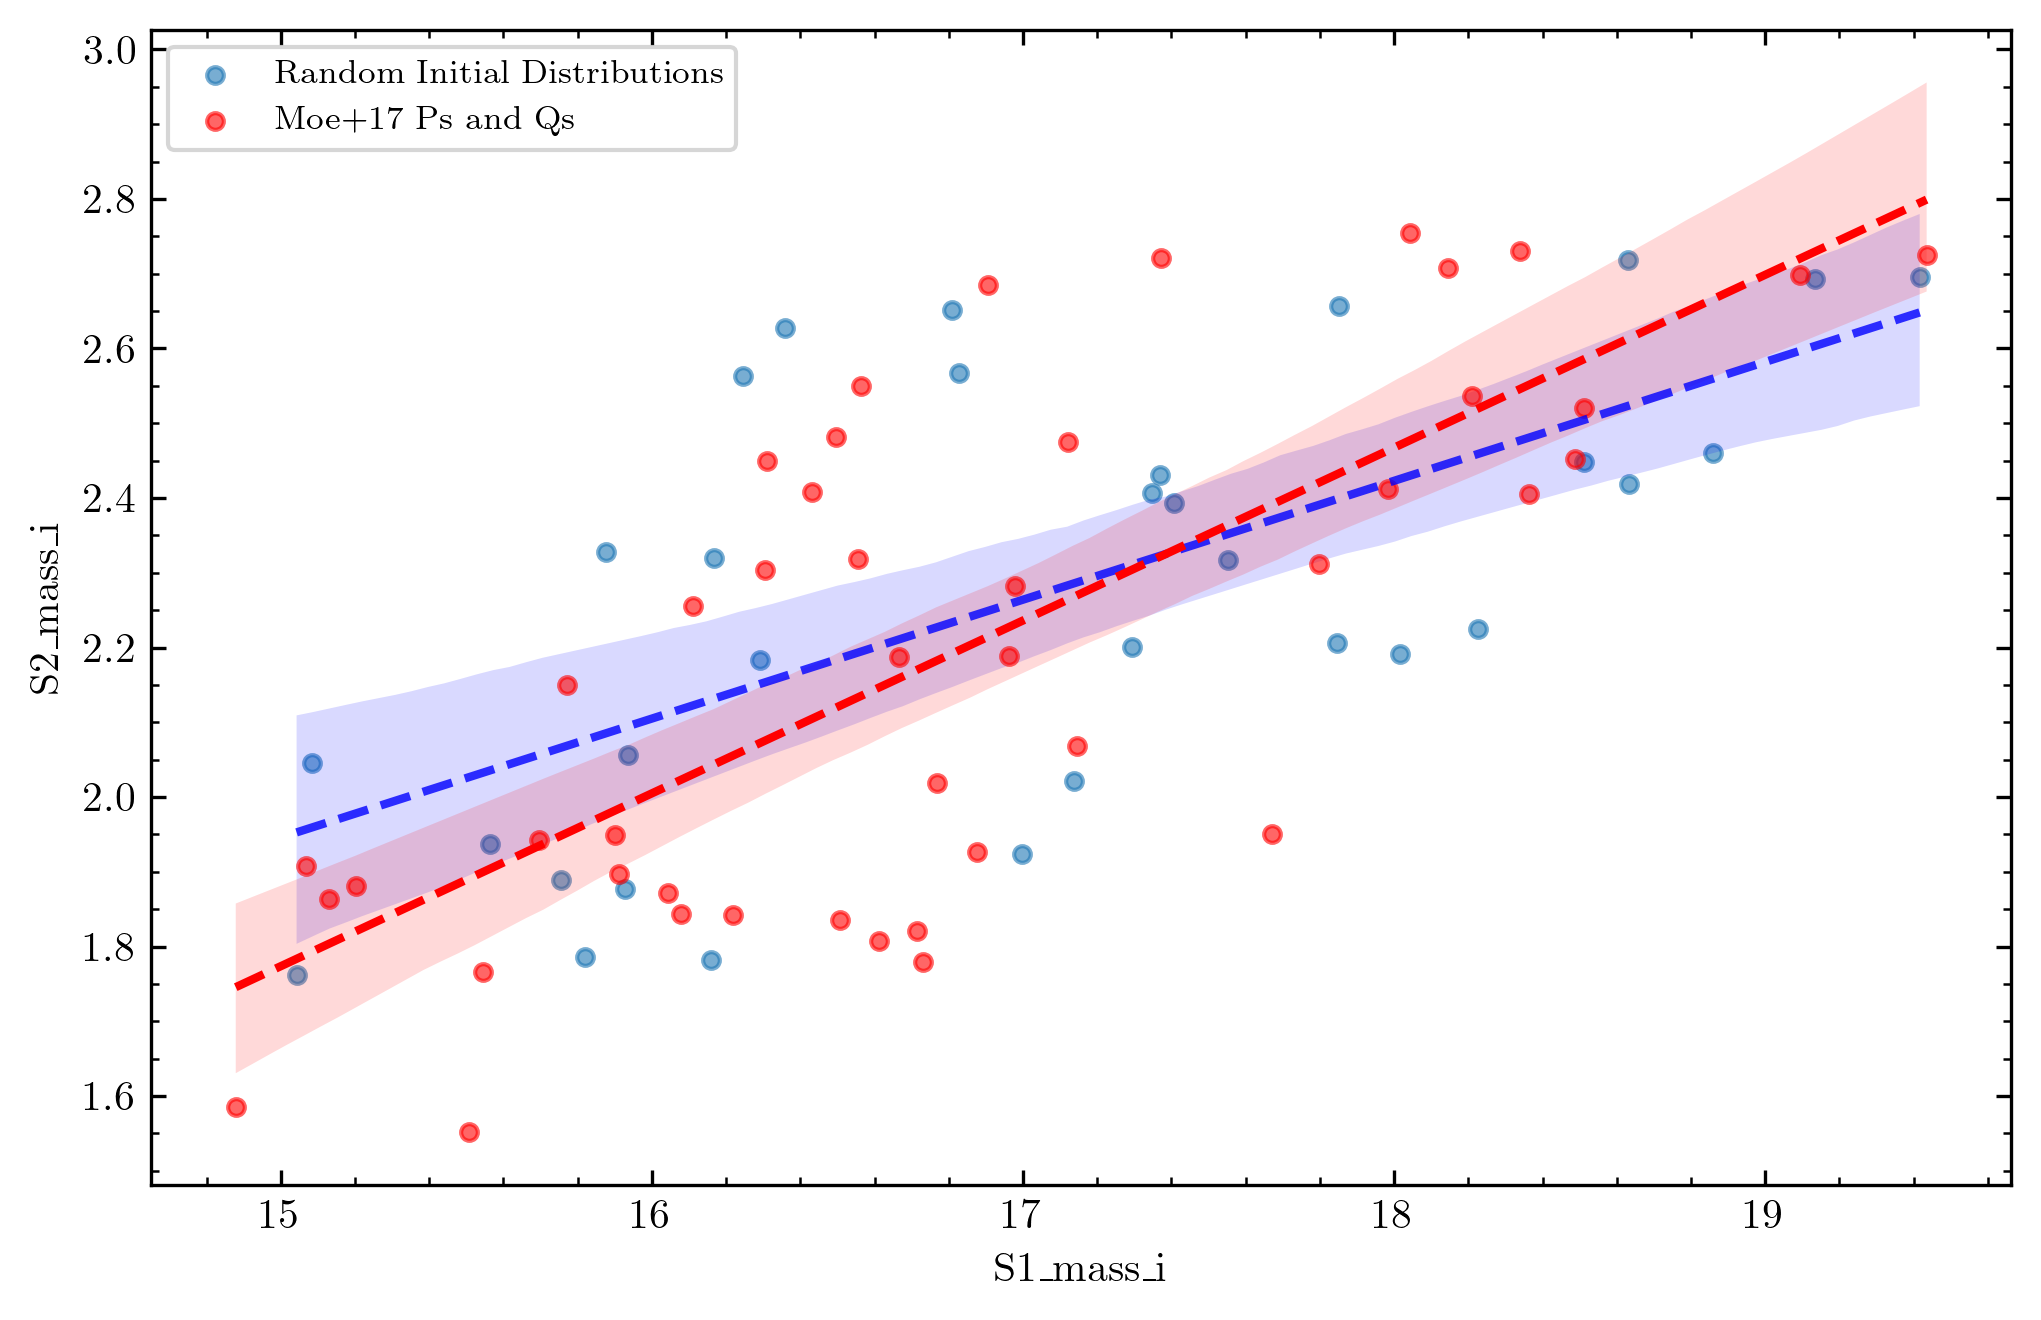

In [105]:
fig, ax = plt.subplots(figsize=(8, 5))

ci = 95

x1,y1 = pOneline['S1_mass_i'],pOneline['S2_mass_i']
x2,y2 = sunlike_pOneline['S1_mass_i'],sunlike_pOneline['S2_mass_i']
x3,y3 = randSamp['S1_mass_i'],randSamp['S2_mass_i']

sns.regplot(x=x1, y=y1, ci=ci, ax=ax,
            line_kws={"color": "blue", "linestyle": "--", "linewidth": 2, "alpha": .8},
            scatter_kws={"alpha": 0.6}, label="Random Initial Distributions")

sns.regplot(x=x2, y=y2, ci=ci, ax=ax, color= 'red',
            line_kws={"color": "red", "linestyle": "--", "linewidth": 2},
            scatter_kws={"alpha": 0.6}, label="Moe+17 Ps and Qs")



plt.savefig(graphSave / 'MoeDistro_Vs_Rand.pgf', bbox_inches='tight')
plt.legend(frameon=True)
plt.show()

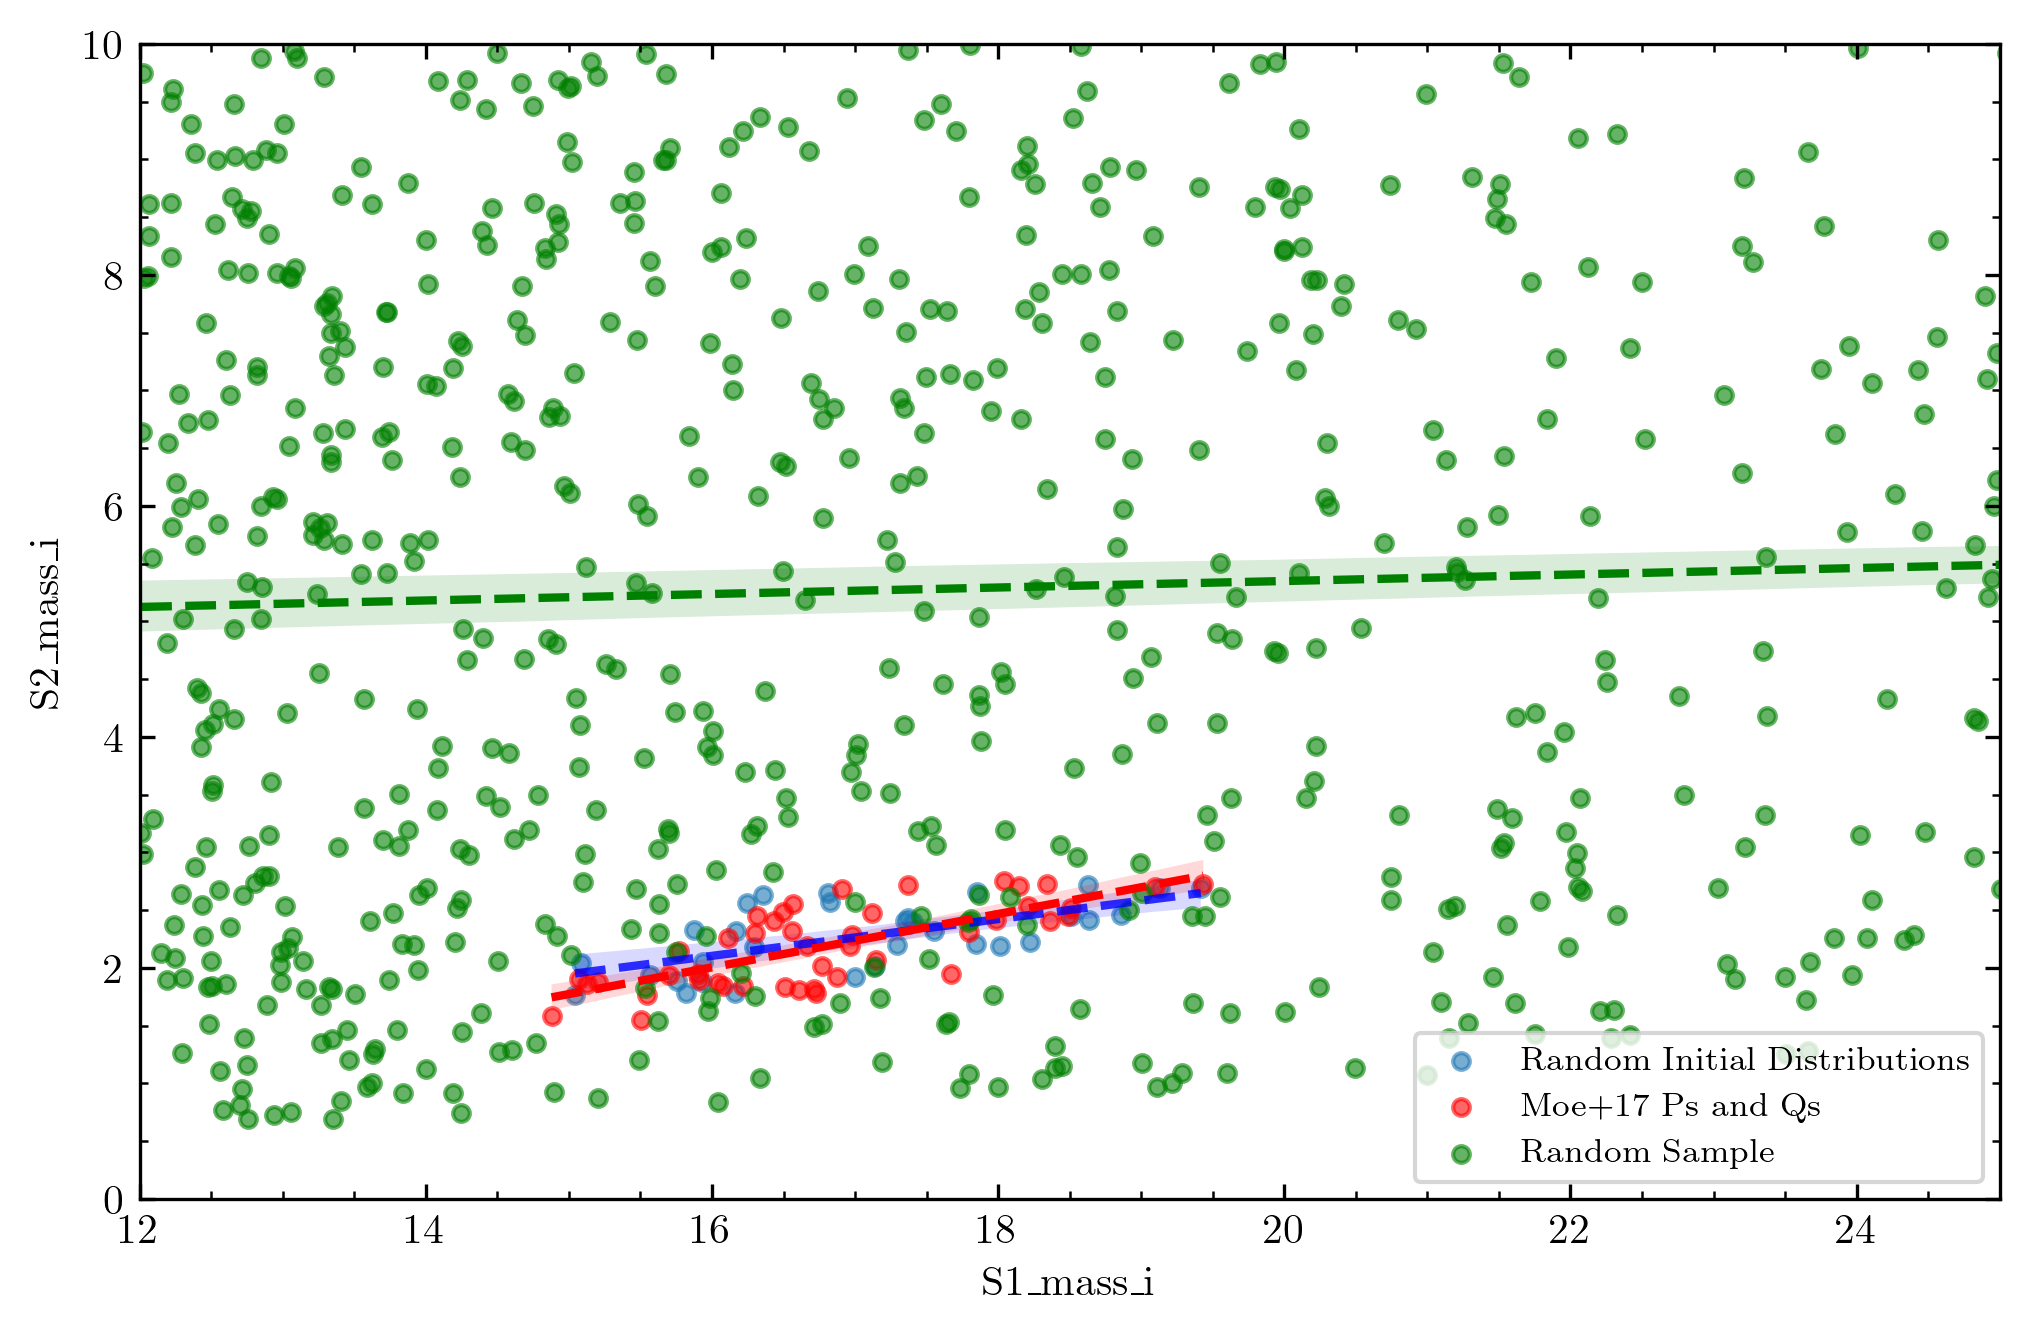

In [106]:
fig, ax = plt.subplots(figsize=(8, 5))

ci = 95

x1,y1 = pOneline['S1_mass_i'],pOneline['S2_mass_i']
x2,y2 = sunlike_pOneline['S1_mass_i'],sunlike_pOneline['S2_mass_i']
x3,y3 = randSamp['S1_mass_i'],randSamp['S2_mass_i']

sns.regplot(x=x1, y=y1, ci=ci, ax=ax,
            line_kws={"color": "blue", "linestyle": "--", "linewidth": 2, "alpha": .8},
            scatter_kws={"alpha": 0.6}, label="Random Initial Distributions")

sns.regplot(x=x2, y=y2, ci=ci, ax=ax, color= 'red',
            line_kws={"color": "red", "linestyle": "--", "linewidth": 2},
            scatter_kws={"alpha": 0.6}, label="Moe+17 Ps and Qs")

sns.regplot(x=x3, y=y3, ci=ci, ax=ax, color= 'green',
            line_kws={"color": "green", "linestyle": "--", "linewidth": 2},
            scatter_kws={"alpha": 0.6}, label="Random Sample")

ax.set_xlim(12,25)
ax.set_ylim(0,10)

plt.savefig(graphSave / 'MoeDistro_Vs_Rand_Vs_All.pgf', bbox_inches='tight')
plt.legend(frameon=True)
plt.show()

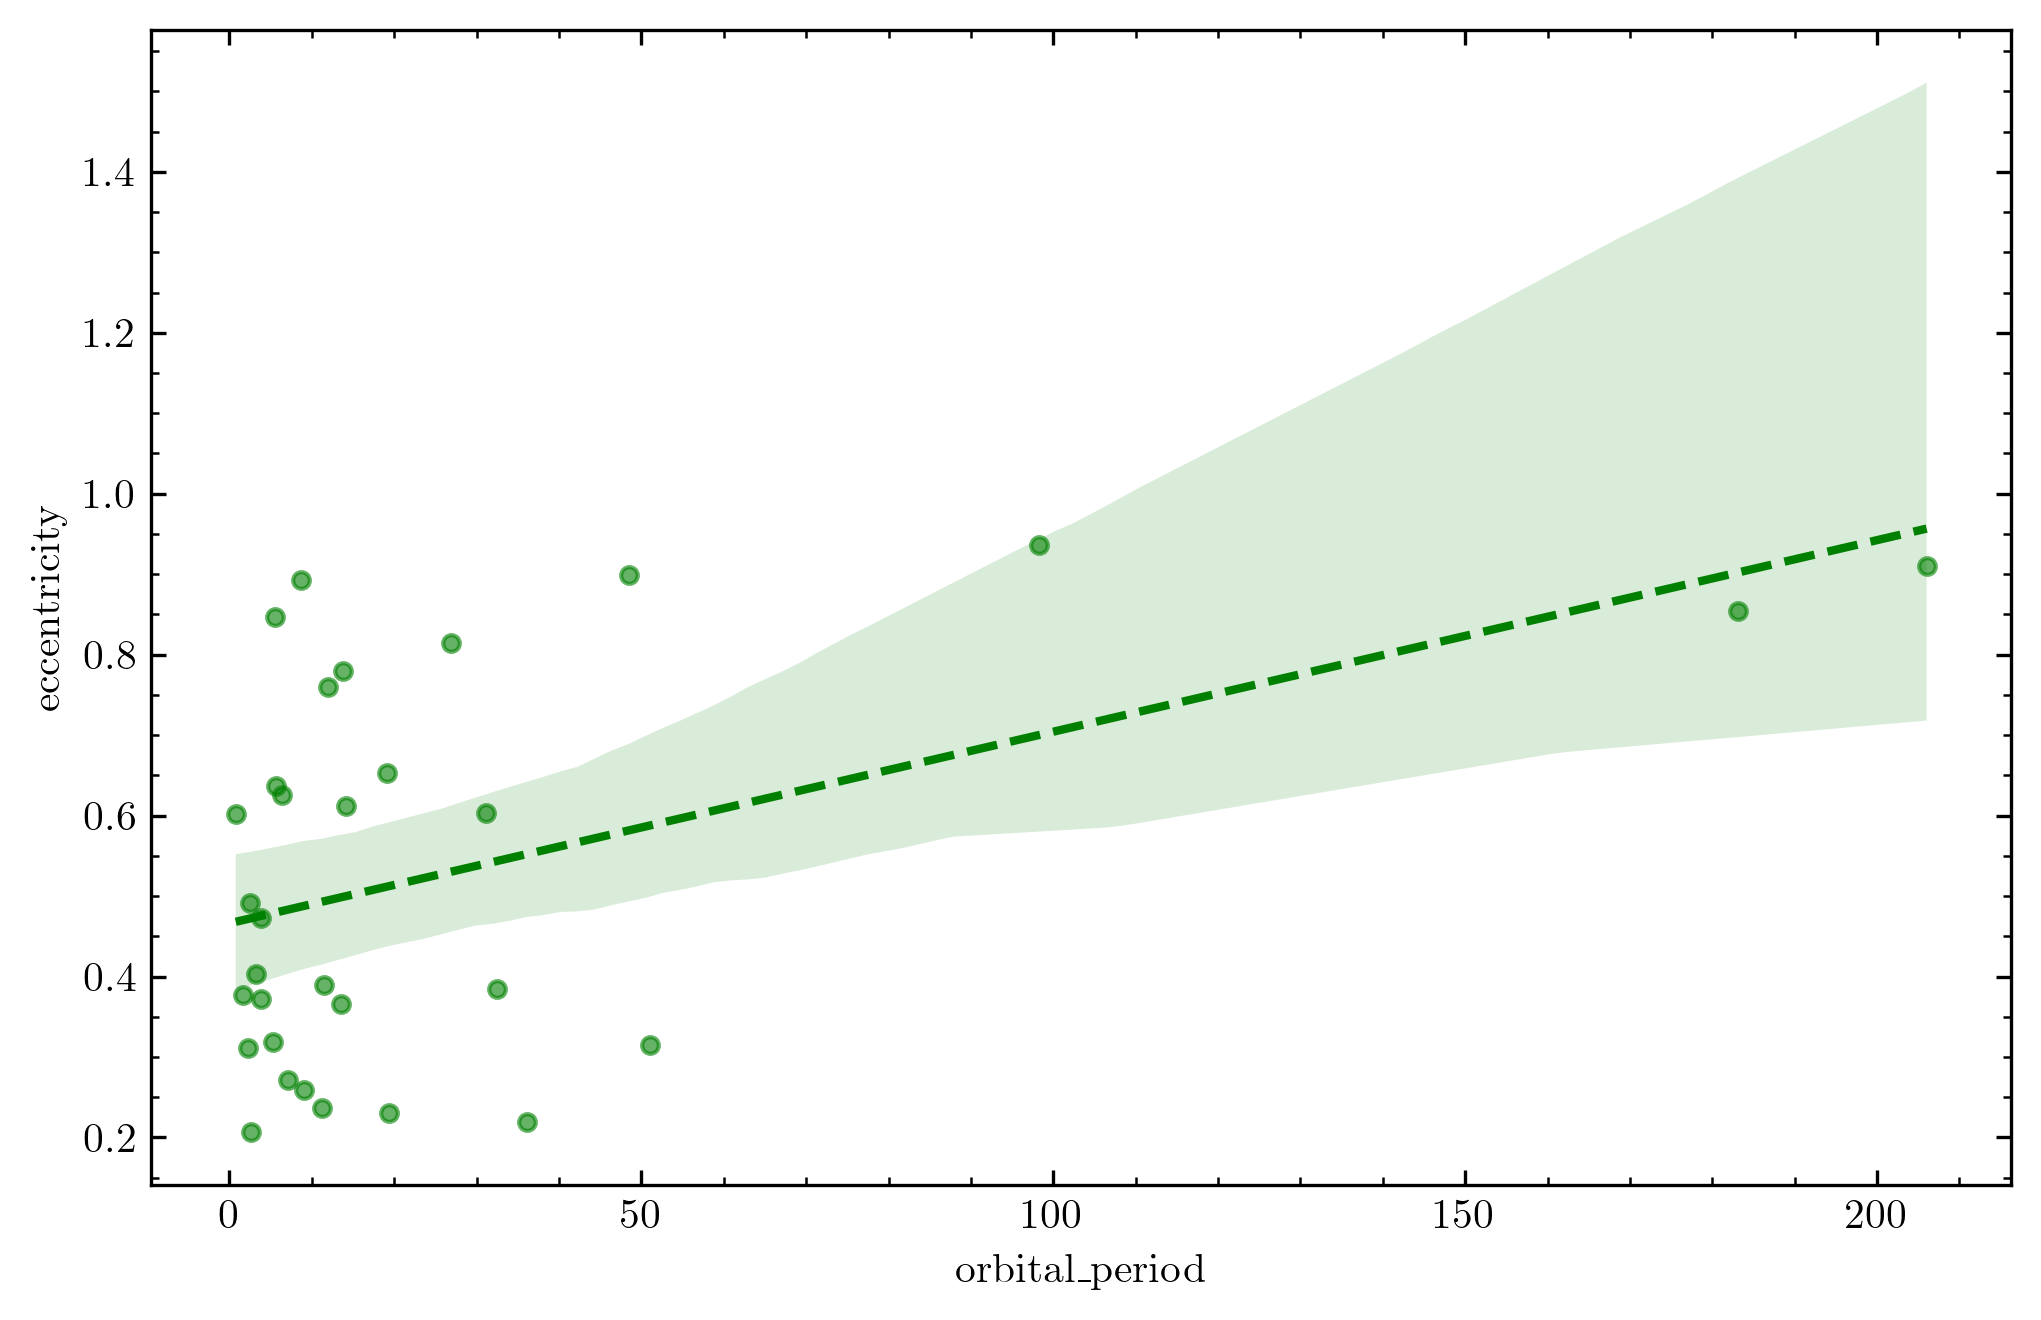

In [99]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.regplot(data = bhSolRows, x='orbital_period', y='eccentricity', ci=ci, ax=ax, color= 'green',
            line_kws={"color": "green", "linestyle": "--", "linewidth": 2},
            scatter_kws={"alpha": 0.6}, label="Random Sample")

plt.show()

In [100]:
SunLike_bhSolRows['orbital_period']

0       1.494220
1       1.884652
2       2.740360
3       0.796016
4       3.317456
5       6.844816
6       7.859836
7      52.749603
8      15.899186
9      14.974814
10     17.206798
11      4.314119
12      2.448846
13     10.076221
14      4.212360
15     22.673620
16    190.296092
18     11.747898
19     30.606112
20      3.749132
21     97.150411
22     96.805112
23     21.302996
24     25.968059
25    115.276003
26      1.593837
27     31.306367
28     12.031967
29      6.201866
30     16.027637
31      1.810091
32      5.708641
33      2.200238
34      2.831847
35      2.121067
36      9.757886
37     21.722308
38      7.901438
39      8.354087
40     23.211976
41      7.609664
42      2.080105
43     22.924889
44     22.285141
45      4.921996
Name: orbital_period, dtype: float64

In [101]:
sunlike_pOneline['S1_natal_kick_velocity']

binary_index
0     271.903612
1      87.409341
2     139.253475
3     271.048494
4     294.292674
5     124.883528
6     198.952850
7     134.536615
8      93.175783
9     129.996389
10    158.616856
11    113.741639
12    125.783547
13    259.298013
14    142.553047
15     79.661442
16    104.683609
18    136.267512
19    140.376590
20    129.199428
21     71.664632
22    150.824051
23    149.591012
24    123.288513
25    159.105162
26    154.194500
27    167.240422
28    102.996976
29    320.149175
30     89.161052
31    239.560720
32    152.467723
33    159.596163
34    192.369247
35    122.147174
36     41.397765
37    178.890926
38    150.264462
39     97.300368
40    123.638649
41    186.173735
42    138.669424
43    130.694925
44     95.168071
45    160.805244
Name: S1_natal_kick_velocity, dtype: float64

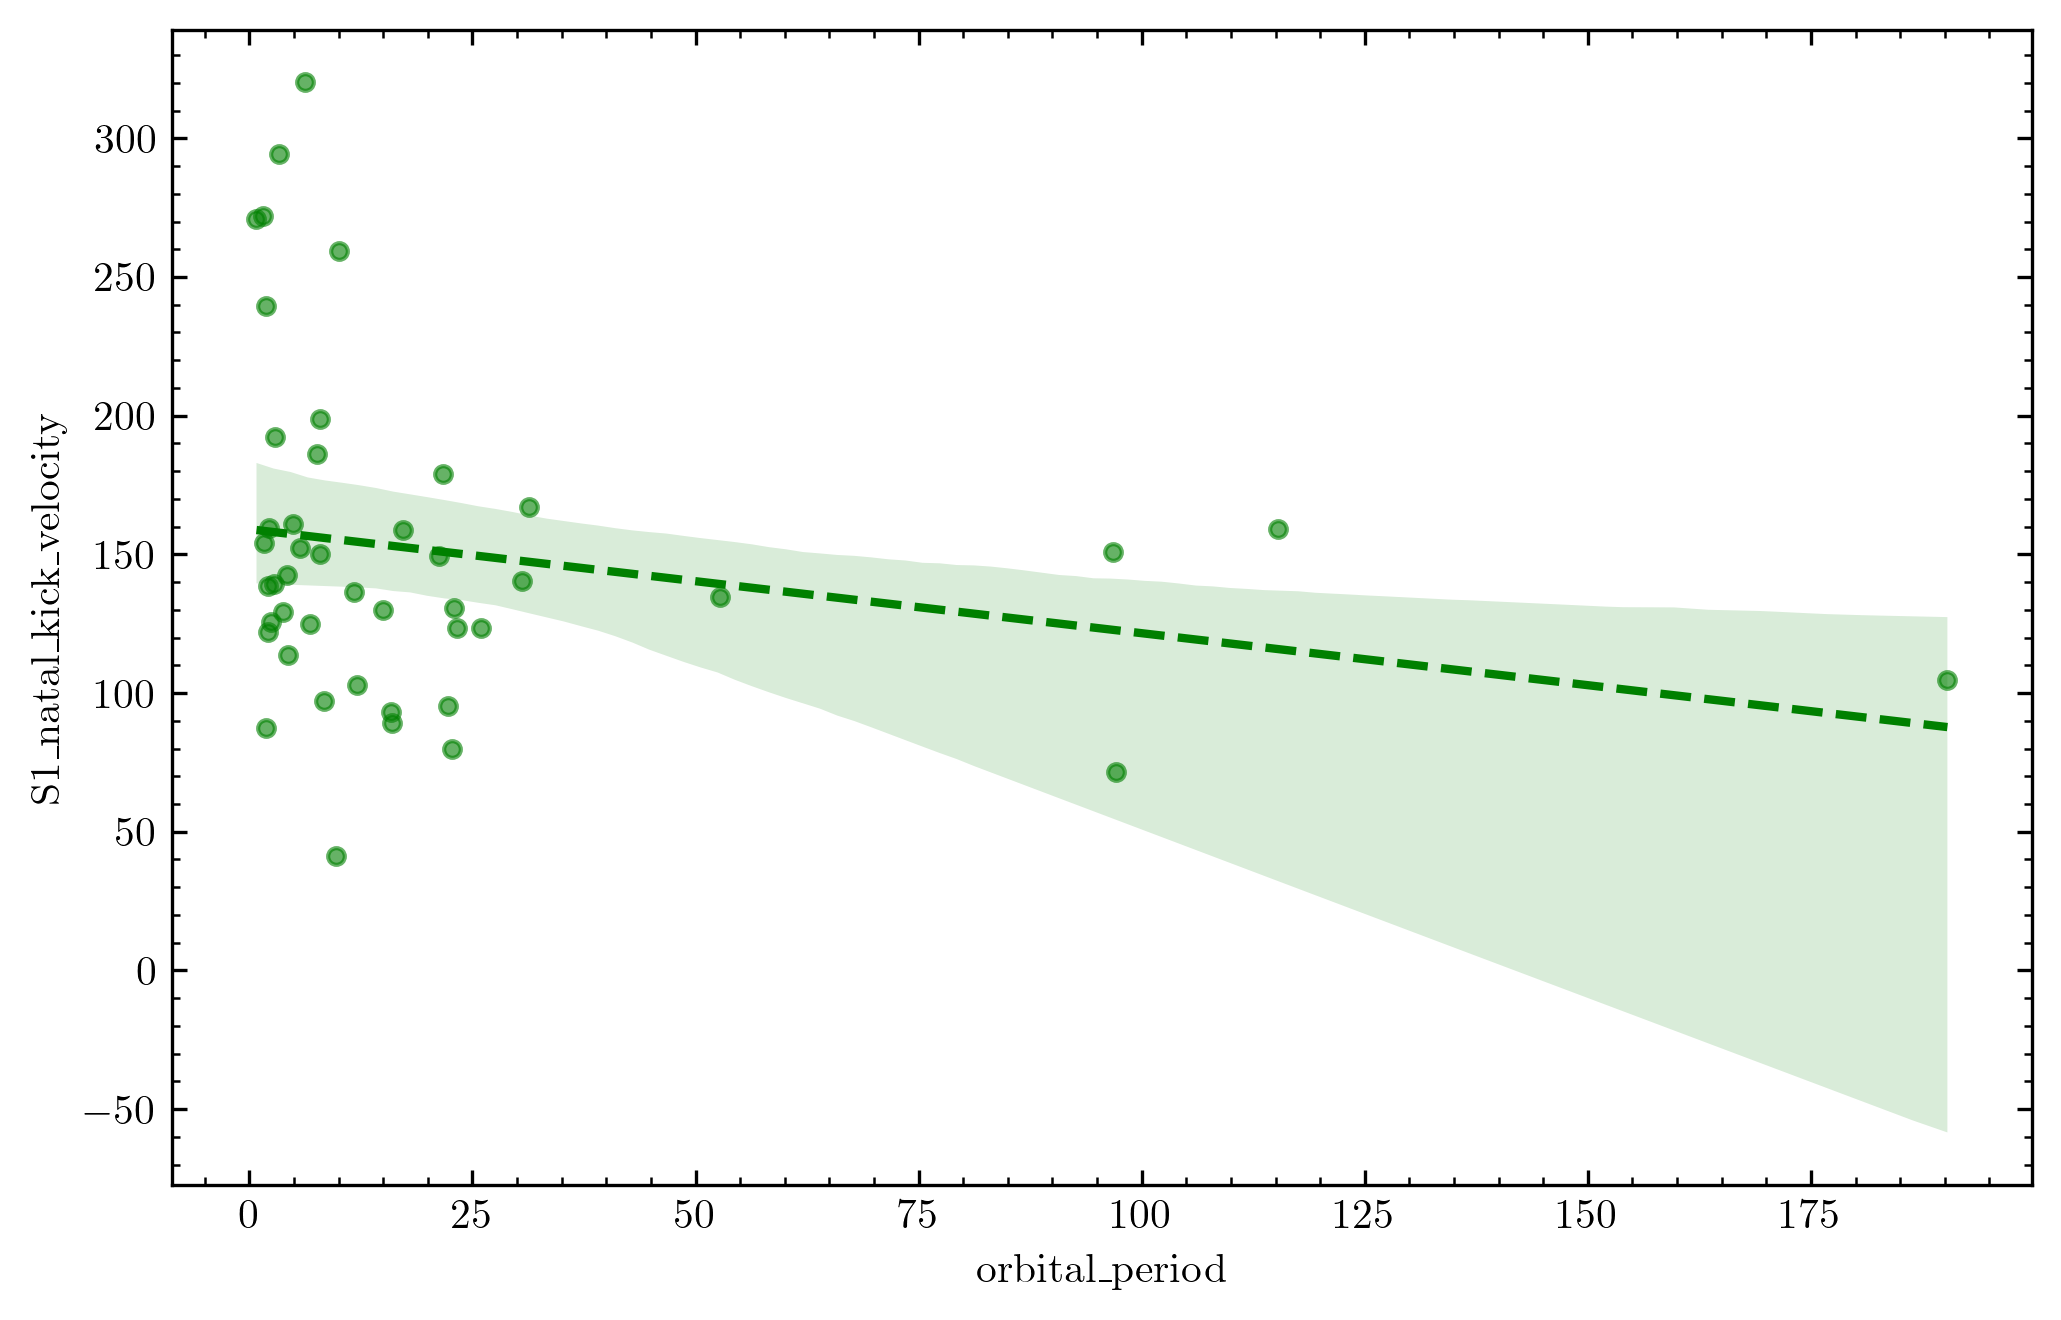

In [102]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.regplot( x=SunLike_bhSolRows['orbital_period'], y=sunlike_pOneline['S1_natal_kick_velocity'], ci=ci, ax=ax, color= 'green',
            line_kws={"color": "green", "linestyle": "--", "linewidth": 2},
            scatter_kws={"alpha": 0.6}, label="Random Sample")

plt.show()